# FundPilot TR

## 1. Proje Tanımı ve Amaç

**Problem:** Bir kitle fonlama kampanyası başlamadan önce, kampanya öncesinde bilinen özellikler kullanılarak kampanyanın başarılı ya da başarısız olarak sonuçlanacağının tahmin edilmesi hedeflenmektedir.

**Hedef değişken:** `basari_durumu` (başarılı / başarısız)

**Problem türü:** İkili sınıflandırma (Binary Classification)

**Kime faydalı:** Bu tahmin, kampanyasını henüz başlatmamış proje sahiplerine; platform seçimi, tanıtım videosu, hedef miktarı, kampanya süresi ve ekip büyüklüğü gibi özelliklerin geçmişte başarı ile ne ölçüde bir arada gözlendiğini görme imkânı sunar. Kitle fonlama platformları da kampanya onaylama ve yönlendirme süreçlerinde bu tahmini bir karar destek girdisi olarak kullanabilir.

**Neden önemli:** Bu veri setindeki kampanyaların yaklaşık %76.9'u hedeflenen tutara ulaşamamıştır. Kampanya başlamadan önce başarı olasılığı hakkında fikir verebilen bir sistem, proje sahiplerinin kampanya stratejisini gözden geçirmesine katkı sağlayabilir. Model, kesin bir sonuç garantisi değil; kampanya öncesi bir karar destek çıktısı üretmeyi amaçlamaktadır.

## 2. Kütüphanelerin Yüklenmesi

Analiz ve modelleme için gerekli kütüphaneler yüklenir.

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

pd.set_option("display.max_columns", None)

## 3. Veri Setinin Yüklenmesi

Veri seti `turkishCF.csv` dosyasından okunur.

In [1]:
df = pd.read_csv("turkishCF.csv", sep=";", encoding="utf-8-sig")
df.head()

,id,platform_adi,kitle_fonlamasi_turu,kategori,fon_sekli,proje_adi,proje_sahibi,proje_sahibi_cinsiyet,kac_proje_destekledi,kac_projeye_abone,kac_projenin_sahibi,kac_proje_takiminda,konum,bolge,yil,proje_baslama_tarihi,proje_bitis_tarihi,gun_sayisi,tanitim_videosu,video_uzunlugu,gorsel_sayisi,sss,guncellemeler,yorumlar,destekci_sayisi,odul_sayisi,ekip_kisi_sayisi,web_sitesi,sosyal_medya,sm_sayisi,sm_takipci,etiket_sayisi,icerik_kelime_sayisi,proje_aciklamasi,hedef_miktari,toplanan_tutar,destek_orani,basari_durumu
0,1,fongogo,ödül,diğer,ya hep ya hiç,Gerçek Gizlidir Filmleri,Lob Ekibi,belirsiz,1,0,1,0,istanbul,marmara,2014,15.09.2014,16.11.2014,62,var,104,1,0,4,0,150,11,4,yok,var,3,274,0,301,Türkiye’de ilk kez her aşaması ‘online’ olarak...,40000,54410,136%,başarılı
1,2,fongogo,ödül,diğer,ya hep ya hiç,Fongogo - Hayat Bulsun!,Fongogo Team,belirsiz,3,0,2,0,istanbul,marmara,2015,4.05.2015,3.07.2015,60,yok,0,12,0,0,0,51,11,7,yok,var,3,5634,0,167,"Fongogo ekibi olarak büyümek, daha geniş kitle...",50000,50110,100%,başarılı
2,3,fongogo,ödül,diğer,ya hep ya hiç,"PAYLAŞIMIN, SEVGİNİN VE ÇOCUKLARIN İYİLİK EVİ ...",SİNEM CAN,kadın,0,0,2,1,belirsiz,belirsiz,2017,NaN,13.06.2017,60,var,60,8,1,1,1,25,6,2,var,var,2,510,4,413,Çocuklara her şeyin ücretsiz olduğu iyilik evi...,47000,47850,101%,başarılı
3,4,fongogo,ödül,diğer,ya hep ya hiç,Türk Kadının 100.yıl Seyri,Deniz Tutkusu Seyirde,kadın,0,0,1,0,muğla,ege,2019,19.04.2019,18.06.2019,60,var,67,6,0,0,0,45,7,1,var,var,2,3338,5,287,‘Sözde değil Özde İzindeyiz ‘ sloganıyla Atatü...,35000,35450,101%,başarılı
4,5,fongogo,ödül,diğer,ya hep ya hiç,Doğadaki Çocuk,Seren Kutadgu,kadın,2,0,1,0,istanbul,marmara,2019,2.09.2019,1.11.2019,60,var,149,5,0,0,0,105,8,6,yok,var,1,144,3,571,İstanbul'daki çocuk yuvalarında yaşayan dezava...,30000,31250,104%,başarılı


## 4. Veri Setinin Tanınması

Veri setinin boyutu, sütun tipleri ve temel istatistikleri incelenir.

In [2]:
df.shape

(1628, 38)

In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1628 entries, 0 to 1627
Data columns (total 38 columns):
 #   Column                 Non-Null Count  Dtype 
---  ------                 --------------  ----- 
 0   id                     1628 non-null   int64 
 1   platform_adi           1628 non-null   object
 2   kitle_fonlamasi_turu   1628 non-null   object
 3   kategori               1628 non-null   object
 4   fon_sekli              1628 non-null   object
 5   proje_adi              1628 non-null   object
 6   proje_sahibi           1628 non-null   object
 7   proje_sahibi_cinsiyet  1628 non-null   object
 8   kac_proje_destekledi   1628 non-null   int64 
 9   kac_projeye_abone      1628 non-null   int64 
 10  kac_projenin_sahibi    1628 non-null   int64 
 11  kac_proje_takiminda    1628 non-null   int64 
 12  konum                  1628 non-null   object
 13  bolge                  1627 non-null   object
 14  yil                    1628 non-null   int64 
 15  proje_baslama_tarihi 

In [4]:
df.describe().T


,count,mean,std,min,25%,50%,75%,max
id,1628.0,814.500000,470.107435,1.0,407.75,814.5,1221.25,1628.0
kac_proje_destekledi,1628.0,0.429361,2.225029,0.0,0.00,0.0,0.00,31.0
kac_projeye_abone,1628.0,0.000614,0.024784,0.0,0.00,0.0,0.00,1.0
kac_projenin_sahibi,1628.0,1.165848,0.710455,1.0,1.00,1.0,1.00,7.0
kac_proje_takiminda,1628.0,0.052826,0.244744,0.0,0.00,0.0,0.00,4.0
yil,1628.0,2018.042383,2.054583,2011.0,2017.00,2019.0,2020.00,2021.0
gun_sayisi,1628.0,52.004914,15.294526,0.0,45.00,60.0,60.00,118.0
video_uzunlugu,1628.0,67.668305,108.145452,0.0,0.00,46.0,98.25,1651.0
gorsel_sayisi,1628.0,5.036855,7.842166,0.0,1.00,3.0,7.00,221.0
sss,1628.0,0.203317,1.439136,0.0,0.00,0.0,0.00,30.0


In [5]:
df["basari_durumu"].value_counts()

basari_durumu
başarısız    1252
başarılı      376
Name: count, dtype: int64

In [6]:
df["basari_durumu"].value_counts(normalize=True) * 100

basari_durumu
başarısız    76.904177
başarılı     23.095823
Name: proportion, dtype: float64

In [7]:
df["platform_adi"].nunique()

6

In [8]:
df["platform_adi"].value_counts()

platform_adi
fongogo      1075
crowdfon      237
fonbulucu     235
arıkovanı      58
buluşum        13
ideanest       10
Name: count, dtype: int64

In [ ]:
def column_summary(dataframe):
    summary = pd.DataFrame({
        "dtype": dataframe.dtypes,
        "nunique": dataframe.nunique(),
        "missing": dataframe.isnull().sum(),
        "missing_%": (dataframe.isnull().sum() / len(dataframe) * 100).round(2),
        "most_frequent": [
            dataframe[col].value_counts(dropna=False).index[0]
            for col in dataframe.columns
        ]
    })

    return summary

In [9]:
column_summary(df)

,dtype,nunique,missing,missing_%,most_frequent
id,int64,1628,0,0.00,1628
platform_adi,object,6,0,0.00,fongogo
kitle_fonlamasi_turu,object,2,0,0.00,ödül
kategori,object,17,0,0.00,film-video-fotoğraf
fon_sekli,object,2,0,0.00,ya hep ya hiç
proje_adi,object,1607,0,0.00,QUBİT'E HAYAL ORTAĞI OLUN
proje_sahibi,object,1513,0,0.00,Percin Imrek
proje_sahibi_cinsiyet,object,3,0,0.00,erkek
kac_proje_destekledi,int64,16,0,0.00,0
kac_projeye_abone,int64,2,0,0.00,0


## 5. Veri Sözlüğü

Aşağıdaki tabloda ham veri setindeki her sütunun adı, veri tipi ve anlamı özetlenmiştir. Anlamı sütun adından kesin şekilde çıkarılamayan sütunlarda (ör. `sss`) yorum ihtiyatlı şekilde belirtilmiştir.

| Sütun | Tip | Anlamı |
|---|---|---|
| `id` | int64 | Kampanyaya ait benzersiz kimlik numarası |
| `platform_adi` | object | Kampanyanın yayınlandığı kitle fonlama platformu |
| `kitle_fonlamasi_turu` | object | Kitle fonlama türü (ödül / bağış) |
| `kategori` | object | Kampanyanın ait olduğu kategori |
| `fon_sekli` | object | Fonlama modeli ("ya hep ya hiç": hedefe ulaşılmazsa tutar iade edilir; "hepsi kalsın": toplanan tutar her durumda proje sahibinde kalır) |
| `proje_adi` | object | Kampanyanın adı (serbest metin) |
| `proje_sahibi` | object | Proje sahibinin adı (serbest metin) |
| `proje_sahibi_cinsiyet` | object | Proje sahibinin cinsiyeti (kadın / erkek / belirsiz) |
| `kac_proje_destekledi` | int64 | Proje sahibinin platformda daha önce destek verdiği proje sayısı |
| `kac_projeye_abone` | int64 | Proje sahibinin abone olduğu proje sayısı |
| `kac_projenin_sahibi` | int64 | Proje sahibinin (bu kampanya dahil) sahip olduğu proje sayısı |
| `kac_proje_takiminda` | int64 | Proje sahibinin takım üyesi olarak yer aldığı proje sayısı |
| `konum` | object | Kampanyanın konumu (şehir düzeyinde, 66 farklı değer) |
| `bolge` | object | Kampanyanın coğrafi bölgesi (`konum`'un sadeleştirilmiş hali) |
| `yil` | int64 | Kampanyanın başlatıldığı yıl |
| `proje_baslama_tarihi` | object | Kampanyanın başlama tarihi (çok sayıda eksik değer içermektedir) |
| `proje_bitis_tarihi` | object | Kampanyanın bitiş tarihi (çok sayıda eksik değer içermektedir) |
| `gun_sayisi` | int64 | Kampanyanın toplam süresi (gün) |
| `tanitim_videosu` | object | Kampanyada tanıtım videosu bulunup bulunmadığı (var / yok) |
| `video_uzunlugu` | int64 | Tanıtım videosunun uzunluğu (saniye); video yoksa 0 |
| `gorsel_sayisi` | int64 | Kampanya sayfasındaki görsel sayısı |
| `sss` | int64 | Kampanya sayfasındaki sıkça sorulan soru sayısı (muhtemelen kampanya sürecinde oluşur) |
| `guncellemeler` | int64 | Kampanya süresince yapılan güncelleme sayısı |
| `yorumlar` | int64 | Kampanyaya yapılan yorum sayısı |
| `destekci_sayisi` | int64 | Kampanyayı destekleyen kişi sayısı |
| `odul_sayisi` | int64 | Kampanyada sunulan farklı ödül/paket sayısı |
| `ekip_kisi_sayisi` | int64 | Proje ekibindeki kişi sayısı |
| `web_sitesi` | object | Projeye ait web sitesi bulunup bulunmadığı (var / yok) |
| `sosyal_medya` | object | Projenin sosyal medya hesabı bulunup bulunmadığı (var / yok) |
| `sm_sayisi` | int64 | Projenin sahip olduğu sosyal medya hesabı sayısı |
| `sm_takipci` | int64 | Sosyal medya hesaplarındaki toplam takipçi sayısı |
| `etiket_sayisi` | int64 | Kampanya sayfasında kullanılan etiket (tag) sayısı |
| `icerik_kelime_sayisi` | int64 | Kampanya açıklama metninin kelime sayısı |
| `proje_aciklamasi` | object | Kampanyanın açıklama metni (serbest metin) |
| `hedef_miktari` | int64 | Kampanyanın toplamayı hedeflediği tutar |
| `toplanan_tutar` | int64 | Kampanya sonunda fiilen toplanan tutar |
| `destek_orani` | object | `toplanan_tutar` / `hedef_miktari` oranı |
| `basari_durumu` | object | **Hedef değişken.** Kampanyanın başarılı ya da başarısız olarak sonuçlanması |

Bu sütunlardan bir kısmı (`toplanan_tutar`, `destek_orani`, `destekci_sayisi`, `guncellemeler`, `yorumlar` vb.) kampanya sonucunu doğrudan yansıttığı veya kampanya sürecinde oluştuğu için **leakage** riski taşımaktadır; çıkarılma gerekçesi bir sonraki bölümde ayrıntılı olarak açıklanmıştır.

## 6. Veri Temizleme ve Leakage Kontrolü

Modelde kullanılacak sütunlar belirlenirken, kampanya başlamadan önce bilinmesi mümkün olmayan (leakage) değişkenler tespit edilip çıkarılmaktadır.

### Sütun Seçimi ve Leakage Kontrolü

Amaç, kampanya başlamadan önce bilinen bilgilerle `basari_durumu` tahmini yapmaktır.

### Çıkarılacak sütunlar
- `id`
- `proje_adi`
- `proje_sahibi`
- `proje_aciklamasi`
- `proje_baslama_tarihi`
- `proje_bitis_tarihi`

### Leakage nedeniyle çıkarılacaklar
- `guncellemeler`
- `yorumlar`
- `destekci_sayisi`
- `toplanan_tutar`
- `destek_orani`

### Kullanılabilecek adaylar
Platform, kategori, fon şekli, yıl, kampanya süresi, video/görsel bilgileri, ekip büyüklüğü, sosyal medya, hedef miktarı vb. kampanya öncesi bilinen değişkenler.

### İncelenecek şüpheli sütunlar
- `kac_proje_destekledi`
- `kac_projeye_abone`
- `kac_projenin_sahibi`
- `kac_proje_takiminda`
- `sss`
- `sm_takipci`

Bu değişkenlerin tahmin anında gerçekten biliniyor olup olmadığı kontrol edildikten sonra karar verilecektir.

### Hedef
`basari_durumu` → başarılı / başarısız

Problem türü: **Binary Classification**

In [10]:
profile_cols = [
    "kac_proje_destekledi",
    "kac_projeye_abone",
    "kac_projenin_sahibi",
    "kac_proje_takiminda"
]

df[profile_cols].describe().T

,count,mean,std,min,25%,50%,75%,max
kac_proje_destekledi,1628.0,0.429361,2.225029,0.0,0.0,0.0,0.0,31.0
kac_projeye_abone,1628.0,0.000614,0.024784,0.0,0.0,0.0,0.0,1.0
kac_projenin_sahibi,1628.0,1.165848,0.710455,1.0,1.0,1.0,1.0,7.0
kac_proje_takiminda,1628.0,0.052826,0.244744,0.0,0.0,0.0,0.0,4.0


In [11]:
for col in profile_cols:
    print(f"\n--- {col} ---")
    print(df[col].value_counts().sort_index())


--- kac_proje_destekledi ---
kac_proje_destekledi
0     1435
1       85
2       40
3       25
4       12
5        6
6        2
7        2
8        1
9        5
11       3
12       1
17       1
18       4
22       2
31       4
Name: count, dtype: int64

--- kac_projeye_abone ---
kac_projeye_abone
0    1627
1       1
Name: count, dtype: int64

--- kac_projenin_sahibi ---
kac_projenin_sahibi
1    1487
2      91
3      24
4       3
6      16
7       7
Name: count, dtype: int64

--- kac_proje_takiminda ---
kac_proje_takiminda
0    1547
1      78
2       2
4       1
Name: count, dtype: int64


In [12]:
df.duplicated().sum()

np.int64(0)

### Profil Değişkenlerinin İlk İncelemesi

Proje sahibinin geçmiş deneyimini temsil eden dört değişken incelendi.

- `kac_proje_destekledi`: Çoğu gözlemde 0 olsa da 1–31 arasında farklı değerler bulunduğu için bilgi taşıyabilir.
- `kac_projeye_abone`: 1628 gözlemin 1627’sinde 0 olduğu için neredeyse sabit bir değişkendir ve modele katkısının düşük olması beklenir.
- `kac_projenin_sahibi`: 1–7 arasında değişmektedir. Proje sahibinin deneyimini temsil edebilir; ancak mevcut projeyi de sayıyor olabileceği için dikkatli yorumlanmalıdır.
- `kac_proje_takiminda`: Çoğunlukla 0 olsa da bazı gözlemlerde farklı değerler bulunduğu için incelenmeye devam edilebilir.

Bu aşamada `kac_projeye_abone` çıkarılmaya adaydır; diğer üç değişken analizde tutulacaktır.

In [13]:
df["sss"].value_counts().sort_index()

sss
0     1519
1       70
2        7
3       12
4        4
5        2
6        2
7        1
8        2
10       2
11       1
12       1
17       1
18       1
19       1
23       1
30       1
Name: count, dtype: int64

In [14]:
df["sss"].describe()

count    1628.000000
mean        0.203317
std         1.439136
min         0.000000
25%         0.000000
50%         0.000000
75%         0.000000
max        30.000000
Name: sss, dtype: float64

In [15]:
df["sm_takipci"].describe()

count      1628.000000
mean       2541.066953
std       19468.390705
min           0.000000
25%           0.000000
50%           4.000000
75%         498.250000
max      534300.000000
Name: sm_takipci, dtype: float64

In [16]:
(df["sm_takipci"] == 0).value_counts()

sm_takipci
False    834
True     794
Name: count, dtype: int64

### Şüpheli Değişkenlerin İncelenmesi

- `sss`: Gözlemlerin büyük çoğunluğunda 0'dır ve kampanya sürecinde oluşabilecek bir bilgi olduğundan leakage riski taşır. Bu nedenle modelden çıkarılmıştır.
- `sm_takipci`: Değişken projeler arasında farklılık göstermektedir; ancak takipçi sayısının hangi tarihte ölçüldüğü net değildir. Tahmin anında mevcut olduğu garanti edilemediği için ana modelden çıkarılmıştır.

In [ ]:
drop_cols = [
    "id",
    "proje_adi",
    "proje_sahibi",
    "proje_aciklamasi",
    "proje_baslama_tarihi",
    "proje_bitis_tarihi",
    "kac_projeye_abone",
    "sss",
    "guncellemeler",
    "yorumlar",
    "destekci_sayisi",
    "sm_takipci",
    "toplanan_tutar",
    "destek_orani"
]

In [ ]:
df_model = df.drop(columns=drop_cols).copy()

In [17]:
df_model.shape

(1628, 24)

In [18]:
df_model.columns.tolist()

['platform_adi',
 'kitle_fonlamasi_turu',
 'kategori',
 'fon_sekli',
 'proje_sahibi_cinsiyet',
 'kac_proje_destekledi',
 'kac_projenin_sahibi',
 'kac_proje_takiminda',
 'konum',
 'bolge',
 'yil',
 'gun_sayisi',
 'tanitim_videosu',
 'video_uzunlugu',
 'gorsel_sayisi',
 'odul_sayisi',
 'ekip_kisi_sayisi',
 'web_sitesi',
 'sosyal_medya',
 'sm_sayisi',
 'etiket_sayisi',
 'icerik_kelime_sayisi',
 'hedef_miktari',
 'basari_durumu']

## 7. Eksik Değer ve Duplicate Analizi

Yinelenen kayıt kontrolü veri temizleme aşamasında yapılmış ve mükerrer kayıt bulunmamıştır (`df.duplicated().sum()` sonucu 0). Bu bölümde eksik değerler ve coğrafi değişken (`bolge` / `konum`) incelenmektedir.

In [19]:
df_model.isnull().sum().sort_values(ascending=False)

bolge                    1
platform_adi             0
kategori                 0
kitle_fonlamasi_turu     0
proje_sahibi_cinsiyet    0
kac_proje_destekledi     0
kac_projenin_sahibi      0
fon_sekli                0
kac_proje_takiminda      0
konum                    0
yil                      0
gun_sayisi               0
tanitim_videosu          0
video_uzunlugu           0
gorsel_sayisi            0
odul_sayisi              0
ekip_kisi_sayisi         0
web_sitesi               0
sosyal_medya             0
sm_sayisi                0
etiket_sayisi            0
icerik_kelime_sayisi     0
hedef_miktari            0
basari_durumu            0
dtype: int64

In [20]:
df_model[df_model["bolge"].isnull()][["konum", "bolge"]]

,konum,bolge
600,lefkoşa,NaN


In [21]:
df_model[df_model["konum"] == "lefkoşa"]

,platform_adi,kitle_fonlamasi_turu,kategori,fon_sekli,proje_sahibi_cinsiyet,kac_proje_destekledi,kac_projenin_sahibi,kac_proje_takiminda,konum,bolge,yil,gun_sayisi,tanitim_videosu,video_uzunlugu,gorsel_sayisi,odul_sayisi,ekip_kisi_sayisi,web_sitesi,sosyal_medya,sm_sayisi,etiket_sayisi,icerik_kelime_sayisi,hedef_miktari,basari_durumu
600,fongogo,ödül,film-video-fotoğraf,ya hep ya hiç,erkek,0,1,0,lefkoşa,NaN,2018,30,var,61,5,9,3,var,var,1,5,629,30000,başarısız


In [22]:
df_model["bolge"].value_counts(dropna=False)

bolge
marmara       638
belirsiz      367
iç anadolu    165
ege           136
akdeniz       102
genel          97
karadeniz      57
güneydoğu      46
doğu           19
NaN             1
Name: count, dtype: int64

In [ ]:
# "bolge" içinde zaten "belirsiz" kategorisi bulunduğu için eksik değer aynı kategoriyle dolduruluyor.
df_model["bolge"] = df_model["bolge"].fillna("belirsiz")

In [23]:
df_model[["konum", "bolge"]].nunique()

konum    66
bolge     9
dtype: int64

In [24]:
df_model["bolge"].value_counts()

bolge
marmara       638
belirsiz      368
iç anadolu    165
ege           136
akdeniz       102
genel          97
karadeniz      57
güneydoğu      46
doğu           19
Name: count, dtype: int64

In [25]:
df_model["konum"].value_counts().head(15)

konum
istanbul      547
belirsiz      367
ankara        107
genel          97
izmir          76
antalya        58
bursa          29
eskişehir      27
muğla          21
kocaeli        21
adana          21
diyarbakır     14
mersin         13
çanakkale      13
denizli        12
Name: count, dtype: int64

In [ ]:
# Yüksek kardinaliteli "konum" yerine daha sade olan "bolge" kullanılıyor.
df_model = df_model.drop(columns=["konum"])

### Eksik Değer ve Coğrafi Değişken Kontrolü

`bolge` değişkeninde yalnızca 1 eksik değer bulundu. Veri setinde `belirsiz` kategorisi zaten mevcut olduğu için bu eksik değer `belirsiz` olarak dolduruldu ve gözlem korunmuştur.

Ayrıca `konum` 66 farklı kategori içerirken `bolge` yalnızca 9 kategori içerdiğinden, coğrafi bilgiyi daha sade temsil eden `bolge` kullanılmış ve yüksek kardinaliteli `konum` modelden çıkarılmıştır.

In [26]:
df_model.shape

(1628, 23)

In [27]:
df_model.isnull().sum().sum()


np.int64(0)

## 8. Aykırı Değer Analizi

Sayısal değişkenlerdeki aykırı değerler IQR ve MAD tabanlı Modified Z-Score yöntemleriyle incelenmektedir.

In [ ]:
def grab_col_names(dataframe, cat_th=2, car_th=20):
    """
    Veri setindeki kategorik, numerik ve kategorik fakat kardinal değişkenlerin isimlerini verir.
    Not: Kategorik değişkenlerin içerisine numerik görünümlü kategorik değişkenler de dahildir.
    """

    # cat_cols, cat_but_car
    cat_cols = [col for col in dataframe.columns if dataframe[col].dtypes == "O"]

    num_but_cat = [
        col for col in dataframe.columns
        if dataframe[col].nunique() < cat_th
        and dataframe[col].dtypes != "O"
    ]

    cat_but_car = [
        col for col in dataframe.columns
        if dataframe[col].nunique() > car_th
        and dataframe[col].dtypes == "O"
    ]

    cat_cols = cat_cols + num_but_cat
    cat_cols = [col for col in cat_cols if col not in cat_but_car]

    # num_cols
    num_cols = [
        col for col in dataframe.columns
        if dataframe[col].dtypes != "O"
    ]

    num_cols = [
        col for col in num_cols
        if col not in num_but_cat
    ]

    print(f"Observations: {dataframe.shape[0]}")
    print(f"Variables: {dataframe.shape[1]}")
    print(f"cat_cols: {len(cat_cols)}")
    print(f"num_cols: {len(num_cols)}")
    print(f"cat_but_car: {len(cat_but_car)}")
    print(f"num_but_cat: {len(num_but_cat)}")

    return cat_cols, num_cols, cat_but_car

In [28]:
cat_cols, num_cols, cat_but_car = grab_col_names(df_model)

Observations: 1628
Variables: 23
cat_cols: 10
num_cols: 13
cat_but_car: 0
num_but_cat: 0


In [29]:
print("Kategorik:", cat_cols)
print("Sayısal:", num_cols)
print("Kardinal:", cat_but_car)

Kategorik: ['platform_adi', 'kitle_fonlamasi_turu', 'kategori', 'fon_sekli', 'proje_sahibi_cinsiyet', 'bolge', 'tanitim_videosu', 'web_sitesi', 'sosyal_medya', 'basari_durumu']
Sayısal: ['kac_proje_destekledi', 'kac_projenin_sahibi', 'kac_proje_takiminda', 'yil', 'gun_sayisi', 'video_uzunlugu', 'gorsel_sayisi', 'odul_sayisi', 'ekip_kisi_sayisi', 'sm_sayisi', 'etiket_sayisi', 'icerik_kelime_sayisi', 'hedef_miktari']
Kardinal: []


In [ ]:
def outlier_thresholds(dataframe, col_name, q1=0.25, q3=0.75):
    quartile1 = dataframe[col_name].quantile(q1)
    quartile3 = dataframe[col_name].quantile(q3)
    interquantile_range = quartile3 - quartile1
    up_limit = quartile3 + 1.5 * interquantile_range
    low_limit = quartile1 - 1.5 * interquantile_range
    return low_limit, up_limit


def check_outlier(dataframe, col_name):
    low_limit, up_limit = outlier_thresholds(dataframe, col_name)

    if dataframe[
        (dataframe[col_name] > up_limit) |
        (dataframe[col_name] < low_limit)
    ].any(axis=None):
        return True
    else:
        return False

In [30]:
for col in num_cols:
    print(col, check_outlier(df_model, col))

kac_proje_destekledi True
kac_projenin_sahibi True
kac_proje_takiminda True
yil True
gun_sayisi True
video_uzunlugu True
gorsel_sayisi True
odul_sayisi True
ekip_kisi_sayisi True
sm_sayisi False
etiket_sayisi True
icerik_kelime_sayisi True
hedef_miktari True


In [ ]:
def outlier_summary(dataframe, numerical_cols):
    results = []

    for col in numerical_cols:
        low, up = outlier_thresholds(dataframe, col)

        outlier_count = dataframe[
            (dataframe[col] < low) | (dataframe[col] > up)
        ].shape[0]

        results.append({
            "variable": col,
            "low_limit": low,
            "up_limit": up,
            "outlier_count": outlier_count,
            "outlier_%": round(outlier_count / len(dataframe) * 100, 2)
        })

    return pd.DataFrame(results)

In [31]:
outlier_summary(df_model, num_cols)

,variable,low_limit,up_limit,outlier_count,outlier_%
0,kac_proje_destekledi,0.000,0.000,193,11.86
1,kac_projenin_sahibi,1.000,1.000,141,8.66
2,kac_proje_takiminda,0.000,0.000,81,4.98
3,yil,2012.500,2024.500,15,0.92
4,gun_sayisi,22.500,82.500,124,7.62
5,video_uzunlugu,-147.375,245.625,76,4.67
6,gorsel_sayisi,-8.000,16.000,77,4.73
7,odul_sayisi,-2.000,14.000,2,0.12
8,ekip_kisi_sayisi,-0.500,3.500,165,10.14
9,sm_sayisi,-3.000,5.000,0,0.00


In [32]:
# Uç değerler otomatik silinmeden önce gerçek bir veri hatası olup olmadığı kontrol ediliyor.
inspect_cols = [
    "gun_sayisi",
    "video_uzunlugu",
    "gorsel_sayisi",
    "icerik_kelime_sayisi",
    "hedef_miktari"
]

df_model[inspect_cols].describe(
    percentiles=[0.01, 0.05, 0.95, 0.99]
).T

,count,mean,std,min,1%,5%,50%,95%,99%,max
gun_sayisi,1628.0,52.004914,15.294526,0.0,10.00,20.0,60.0,60.00,89.46,118.0
video_uzunlugu,1628.0,67.668305,108.145452,0.0,0.00,0.0,46.0,235.65,387.19,1651.0
gorsel_sayisi,1628.0,5.036855,7.842166,0.0,0.00,0.0,3.0,16.00,26.73,221.0
icerik_kelime_sayisi,1628.0,354.221744,300.196873,0.0,11.54,63.0,277.5,918.80,1407.39,3473.0
hedef_miktari,1628.0,31134.305897,65689.722941,1.0,890.50,2000.0,15000.0,100000.00,250000.00,1453000.0


In [33]:
df_model[df_model["gun_sayisi"] == 0]

,platform_adi,kitle_fonlamasi_turu,kategori,fon_sekli,proje_sahibi_cinsiyet,kac_proje_destekledi,kac_projenin_sahibi,kac_proje_takiminda,bolge,yil,gun_sayisi,tanitim_videosu,video_uzunlugu,gorsel_sayisi,odul_sayisi,ekip_kisi_sayisi,web_sitesi,sosyal_medya,sm_sayisi,etiket_sayisi,icerik_kelime_sayisi,hedef_miktari,basari_durumu
206,fongogo,ödül,eğitim,hepsi kalsın,belirsiz,0,1,0,güneydoğu,2020,0,var,301,5,6,1,var,var,3,5,637,11500,başarısız
513,fongogo,ödül,film-video-fotoğraf,ya hep ya hiç,erkek,0,1,0,marmara,2020,0,yok,0,1,7,2,yok,var,2,5,493,22000,başarısız


In [34]:
df.loc[
    df["gun_sayisi"] == 0,
    [
        "platform_adi",
        "proje_adi",
        "proje_baslama_tarihi",
        "proje_bitis_tarihi",
        "gun_sayisi",
        "basari_durumu"
    ]
]

,platform_adi,proje_adi,proje_baslama_tarihi,proje_bitis_tarihi,gun_sayisi,basari_durumu
206,fongogo,DAYANIŞMANIN EV HALİ,09.04.2020,9.04.2020,0,başarısız
513,fongogo,Karşıdaki / Kısa Film,27.08.2020,27.08.2020,0,başarısız


In [35]:
df_model.nlargest(5, "video_uzunlugu")[
    ["video_uzunlugu", "tanitim_videosu", "kategori", "basari_durumu"]
]

,video_uzunlugu,tanitim_videosu,kategori,basari_durumu
789,1651,var,kültür-sanat,başarısız
33,1589,var,diğer,başarısız
949,1118,var,teknoloji,başarısız
1081,1111,var,çevre,başarısız
260,827,var,eğitim,başarısız


In [36]:
df_model.nlargest(5, "gorsel_sayisi")[
    ["gorsel_sayisi", "kategori", "platform_adi", "basari_durumu"]
]

,gorsel_sayisi,kategori,platform_adi,basari_durumu
298,221,film-video-fotoğraf,fongogo,başarılı
428,57,film-video-fotoğraf,fongogo,başarısız
575,47,film-video-fotoğraf,fongogo,başarısız
366,43,film-video-fotoğraf,fongogo,başarılı
151,42,eğitim,fongogo,başarılı


In [37]:
df_model.nlargest(5, "icerik_kelime_sayisi")[
    ["icerik_kelime_sayisi", "kategori", "platform_adi", "basari_durumu"]
]

,icerik_kelime_sayisi,kategori,platform_adi,basari_durumu
1069,3473,çevre,fongogo,başarısız
1576,3155,teknoloji,arıkovanı,başarısız
1258,2374,sağlık-güzellik,fonbulucu,başarılı
236,2087,eğitim,fongogo,başarısız
418,1852,film-video-fotoğraf,fongogo,başarılı


In [38]:
df_model.nlargest(5, "hedef_miktari")[
    ["hedef_miktari", "kategori", "platform_adi", "basari_durumu"]
]

,hedef_miktari,kategori,platform_adi,basari_durumu
1538,1453000,diğer,crowdfon,başarısız
1162,1000000,teknoloji,fonbulucu,başarısız
1080,750000,çevre,fonbulucu,başarısız
287,600000,eğitim,fongogo,başarısız
1035,500000,teknoloji,fongogo,başarısız


In [ ]:
def mad_outlier_summary(dataframe, numerical_cols, threshold=3.5):
    results = []

    for col in numerical_cols:
        median = dataframe[col].median()
        mad = np.median(np.abs(dataframe[col] - median))

        if mad == 0:
            results.append({
                "variable": col,
                "MAD": mad,
                "outlier_count": None,
                "outlier_%": None,
                "status": "MAD = 0"
            })
            continue

        modified_z = 0.6745 * (dataframe[col] - median) / mad
        outlier_count = (np.abs(modified_z) > threshold).sum()

        results.append({
            "variable": col,
            "MAD": round(mad, 3),
            "outlier_count": outlier_count,
            "outlier_%": round(outlier_count / len(dataframe) * 100, 2),
            "status": "OK"
        })

    return pd.DataFrame(results)

In [39]:
mad_summary = mad_outlier_summary(df_model, num_cols)
mad_summary

,variable,MAD,outlier_count,outlier_%,status
0,kac_proje_destekledi,0.0,NaN,NaN,MAD = 0
1,kac_projenin_sahibi,0.0,NaN,NaN,MAD = 0
2,kac_proje_takiminda,0.0,NaN,NaN,MAD = 0
3,yil,1.0,39.0,2.40,OK
4,gun_sayisi,0.0,NaN,NaN,MAD = 0
5,video_uzunlugu,46.0,52.0,3.19,OK
6,gorsel_sayisi,2.0,119.0,7.31,OK
7,odul_sayisi,2.0,1.0,0.06,OK
8,ekip_kisi_sayisi,0.0,NaN,NaN,MAD = 0
9,sm_sayisi,1.0,0.0,0.00,OK


In [40]:
iqr_summary = outlier_summary(df_model, num_cols)

outlier_comparison = iqr_summary[
    ["variable", "outlier_count", "outlier_%"]
].merge(
    mad_summary[
        ["variable", "outlier_count", "outlier_%", "status"]
    ],
    on="variable",
    suffixes=("_IQR", "_MAD")
)

outlier_comparison

,variable,outlier_count_IQR,outlier_%_IQR,outlier_count_MAD,outlier_%_MAD,status
0,kac_proje_destekledi,193,11.86,NaN,NaN,MAD = 0
1,kac_projenin_sahibi,141,8.66,NaN,NaN,MAD = 0
2,kac_proje_takiminda,81,4.98,NaN,NaN,MAD = 0
3,yil,15,0.92,39.0,2.40,OK
4,gun_sayisi,124,7.62,NaN,NaN,MAD = 0
5,video_uzunlugu,76,4.67,52.0,3.19,OK
6,gorsel_sayisi,77,4.73,119.0,7.31,OK
7,odul_sayisi,2,0.12,1.0,0.06,OK
8,ekip_kisi_sayisi,165,10.14,NaN,NaN,MAD = 0
9,sm_sayisi,0,0.00,0.0,0.00,OK


### Aykırı Değer Analizi

Sayısal değişkenlerde aykırı değerleri incelemek amacıyla **IQR (Interquartile Range)** ve **MAD tabanlı Modified Z-Score** yöntemleri kullanılmıştır.

IQR yöntemi bazı değişkenlerde yüksek sayıda uç gözlem tespit etmiştir. Özellikle değerlerin belirli noktalarda yoğunlaştığı sayım değişkenlerinde IQR sınırlarının daralabildiği ve normal fakat nadir gözlemlerin de aykırı olarak işaretlenebildiği görülmüştür.

Bu nedenle analiz, medyan tabanlı ve uç değerlerden daha az etkilenen MAD yöntemi ile desteklenmiştir. Bazı değişkenlerde medyandan mutlak sapmaların medyanı sıfır olduğu için `MAD = 0` elde edilmiş ve Modified Z-Score bu değişkenler için uygulanamamıştır.

Her iki yöntemde belirlenen uç değerler otomatik olarak silinmemiş veya baskılanmamıştır. Kampanya süresi, video uzunluğu, görsel sayısı, içerik kelime sayısı ve hedef miktarı gibi değişkenlerde en uç gözlemler ayrıca incelenmiştir. İnceleme sonucunda açık bir veri giriş hatasına rastlanmadığından gözlemler korunmuştur.

Sonuç olarak, aykırı değer yöntemleri veri kalitesini kontrol etmek amacıyla kullanılmış; gerçek kampanya farklılıklarını temsil edebilecek uç değerlerin gereksiz şekilde değiştirilmesinden kaçınılmıştır.

## 9. Keşifçi Veri Analizi (EDA)

Hedef değişken ile kategorik ve sayısal değişkenler arasındaki ilişkiler görselleştirilerek incelenmektedir.

In [51]:
# Grafiklerde tutarlı bir görünüm için renk paleti ve stil ayarları.
# Renkler (mavi/amber) colorblind-safe olacak şekilde doğrulanmış ve
# sunum/rapor ile aynı marka paletini kullanmaktadır.
C_BLUE = "#2E5FA3"
C_AMBER = "#E8A33D"
C_GRID = "#E1E0D9"
C_INK = "#1E2761"
C_MUTED = "#52514E"

plt.rcParams.update({
    "figure.dpi": 110,
    "axes.spines.top": False,
    "axes.spines.right": False,
    "axes.edgecolor": "#C3C2B7",
    "axes.titleweight": "bold",
    "axes.titlesize": 13,
    "axes.titlecolor": C_INK,
    "axes.labelcolor": C_MUTED,
    "xtick.color": C_MUTED,
    "ytick.color": C_MUTED,
    "axes.axisbelow": True,
    "font.size": 10.5,
})

In [41]:
target_summary = pd.DataFrame({
    "count": df_model["basari_durumu"].value_counts(),
    "percentage": df_model["basari_durumu"]
        .value_counts(normalize=True)
        .mul(100)
        .round(2)
})

target_summary

,count,percentage
basari_durumu,,
başarısız,1252,76.9
başarılı,376,23.1


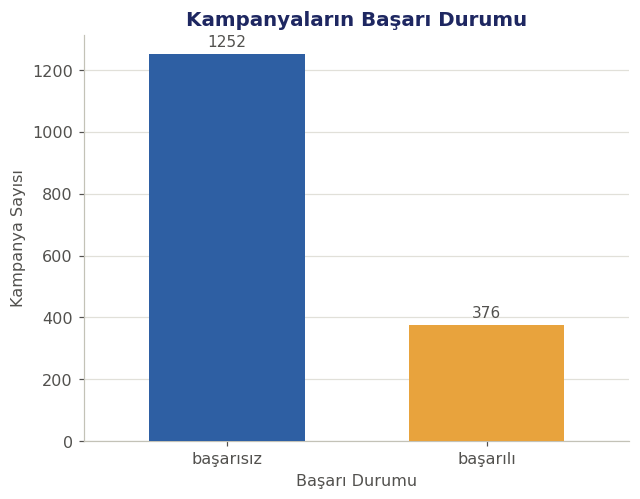

In [53]:
ax = df_model["basari_durumu"].value_counts().plot(
    kind="bar",
    color=[C_BLUE, C_AMBER],
    width=0.6,
    zorder=3,
)

ax.grid(axis="y", color=C_GRID, linewidth=0.8, zorder=0)
ax.bar_label(ax.containers[0], padding=3, color=C_MUTED, fontsize=10)

plt.title("Kampanyaların Başarı Durumu")
plt.xlabel("Başarı Durumu")
plt.ylabel("Kampanya Sayısı")
plt.xticks(rotation=0)
plt.show()


### Hedef Değişken Dağılımı

Veri setindeki kampanyaların %76.9'u başarısız, %23.1'i başarılıdır. Hedef değişken dengeli dağılmadığı için model performansı yalnızca accuracy metriği ile değerlendirilmeyecek; precision, recall, F1-score ve confusion matrix de kullanılacaktır.

In [43]:
category_success = (
    df_model.groupby("kategori")["basari_durumu"]
    .value_counts(normalize=True)
    .unstack()
    .mul(100)
    .round(2)
)

category_success

basari_durumu,başarılı,başarısız
kategori,,
dans-performans,14.29,85.71
diğer,12.26,87.74
eğitim,32.26,67.74
film-video-fotoğraf,34.45,65.55
gıda-yeme-içme,11.54,88.46
hayvanlar,NaN,100.00
kültür-sanat,19.07,80.93
moda,18.18,81.82
müzik,18.64,81.36


In [44]:
category_summary = (
    df_model.groupby("kategori")
    .agg(
        kampanya_sayisi=("basari_durumu", "size"),
        basarili_sayisi=("basari_durumu", lambda x: (x == "başarılı").sum()),
        basari_orani=("basari_durumu", lambda x: (x == "başarılı").mean() * 100)
    )
    .round(2)
    .sort_values("basari_orani", ascending=False)
)

category_summary

,kampanya_sayisi,basarili_sayisi,basari_orani
kategori,,,
sosyal sorumluluk,10,5,50.00
film-video-fotoğraf,389,134,34.45
sağlık-güzellik,50,17,34.00
turizm,6,2,33.33
eğitim,186,60,32.26
spor,20,5,25.00
çevre,98,22,22.45
kültür-sanat,194,37,19.07
müzik,59,11,18.64


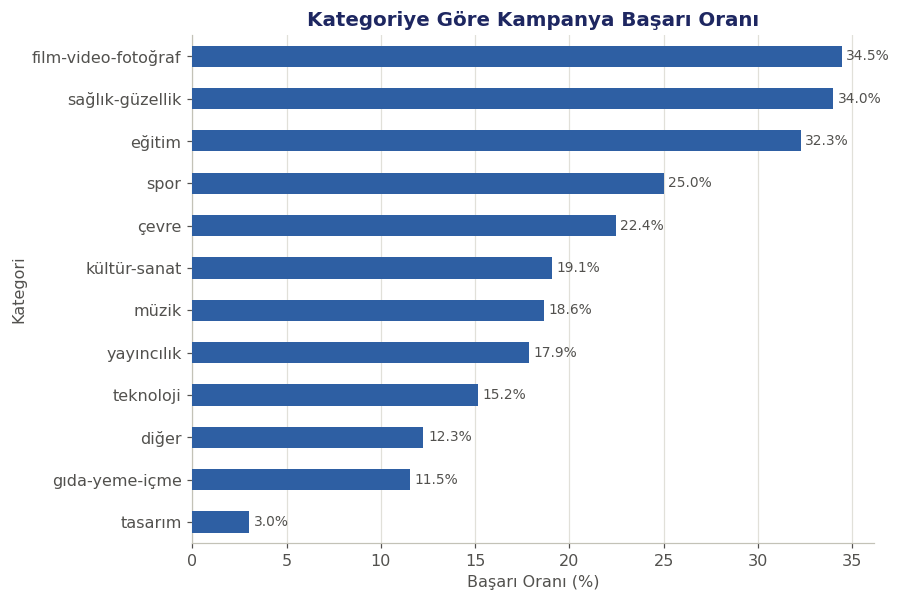

In [56]:
category_plot = category_summary[
    category_summary["kampanya_sayisi"] >= 20
].sort_values("basari_orani")

ax = category_plot["basari_orani"].plot(
    kind="barh",
    figsize=(8, 6),
    color=C_BLUE,
    zorder=3,
)

ax.grid(axis="x", color=C_GRID, linewidth=0.8, zorder=0)
ax.bar_label(ax.containers[0], fmt="%.1f%%", padding=3, color=C_MUTED, fontsize=9)

plt.title("Kategoriye Göre Kampanya Başarı Oranı")
plt.xlabel("Başarı Oranı (%)")
plt.ylabel("Kategori")
plt.show()

Kategori bazında başarı oranları farklılık göstermektedir. Ancak kampanya sayısı düşük kategorilerdeki oranların daha değişken olabileceği göz önünde bulundurulmalıdır. En az 20 kampanya içeren kategoriler incelendiğinde, film-video-fotoğraf ve eğitim kategorilerinin başarı oranları genel başarı oranının üzerinde; teknoloji, kültür-sanat ve diğer kategorilerinin ise altında kalmaktadır.

In [46]:
platform_summary = (
    df_model.groupby("platform_adi")
    .agg(
        kampanya_sayisi=("basari_durumu", "size"),
        basarili_sayisi=("basari_durumu", lambda x: (x == "başarılı").sum()),
        basari_orani=("basari_durumu", lambda x: (x == "başarılı").mean() * 100)
    )
    .round(2)
    .sort_values("basari_orani", ascending=False)
)

platform_summary

,kampanya_sayisi,basarili_sayisi,basari_orani
platform_adi,,,
buluşum,13,13,100.00
ideanest,10,9,90.00
arıkovanı,58,39,67.24
fongogo,1075,284,26.42
crowdfon,237,16,6.75
fonbulucu,235,15,6.38


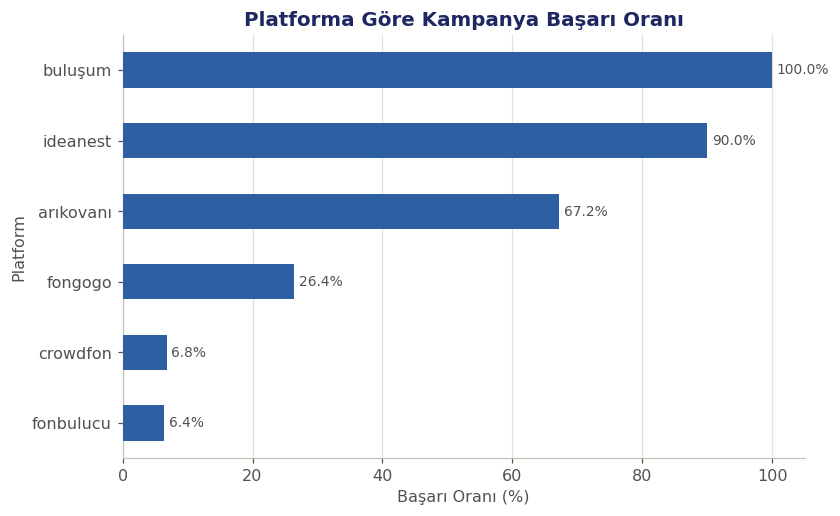

In [58]:
ax = platform_summary.sort_values("basari_orani")["basari_orani"].plot(
    kind="barh",
    figsize=(8, 5),
    color=C_BLUE,
    zorder=3,
)

ax.grid(axis="x", color=C_GRID, linewidth=0.8, zorder=0)
ax.bar_label(ax.containers[0], fmt="%.1f%%", padding=3, color=C_MUTED, fontsize=9)

plt.title("Platforma Göre Kampanya Başarı Oranı")
plt.xlabel("Başarı Oranı (%)")
plt.ylabel("Platform")
plt.show()

Platformlar arasında başarı oranlarının belirgin şekilde farklılaştığı görülmektedir. Ancak Buluşum ve Ideamest gibi az sayıda kampanya içeren platformlarda oranların küçük örneklem nedeniyle daha değişken olabileceği dikkate alınmalıdır. Platform değişkeni kampanya başlamadan önce bilindiği için modelde kullanılabilir; ancak gözlenen farklılıklar nedensel olarak yorumlanmamalıdır.

In [48]:
type_summary = (
    df_model.groupby("kitle_fonlamasi_turu")
    .agg(
        kampanya_sayisi=("basari_durumu", "size"),
        basarili_sayisi=("basari_durumu", lambda x: (x == "başarılı").sum()),
        basari_orani=("basari_durumu", lambda x: (x == "başarılı").mean() * 100)
    )
    .round(2)
    .sort_values("basari_orani", ascending=False)
)

type_summary

,kampanya_sayisi,basarili_sayisi,basari_orani
kitle_fonlamasi_turu,,,
bağış,10,9,90.00
ödül,1618,367,22.68


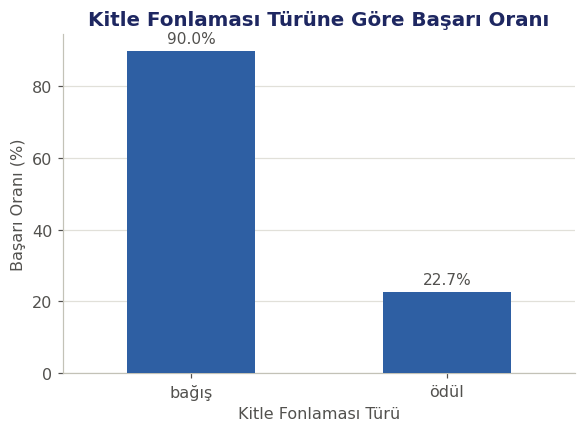

In [60]:
ax = type_summary["basari_orani"].plot(
    kind="bar",
    figsize=(6, 4),
    color=C_BLUE,
    width=0.5,
    zorder=3,
)

ax.grid(axis="y", color=C_GRID, linewidth=0.8, zorder=0)
ax.bar_label(ax.containers[0], fmt="%.1f%%", padding=3, color=C_MUTED, fontsize=10)

plt.title("Kitle Fonlaması Türüne Göre Başarı Oranı")
plt.xlabel("Kitle Fonlaması Türü")
plt.ylabel("Başarı Oranı (%)")
plt.xticks(rotation=0)
plt.show()

Kitle fonlaması türlerine göre başarı oranlarında belirgin bir fark görülmektedir. Bağış türünde başarı oranı %90 iken ödül türünde %22.68'dir. Ancak bağış türünde yalnızca 10 kampanya bulunduğu için bu yüksek oran küçük örneklem nedeniyle dikkatli yorumlanmalıdır.

In [50]:
funding_shape_summary = (
    df_model.groupby("fon_sekli")
    .agg(
        kampanya_sayisi=("basari_durumu", "size"),
        basarili_sayisi=("basari_durumu", lambda x: (x == "başarılı").sum()),
        basari_orani=("basari_durumu", lambda x: (x == "başarılı").mean() * 100)
    )
    .round(2)
    .sort_values("basari_orani", ascending=False)
)

funding_shape_summary

,kampanya_sayisi,basarili_sayisi,basari_orani
fon_sekli,,,
ya hep ya hiç,1509,353,23.39
hepsi kalsın,119,23,19.33


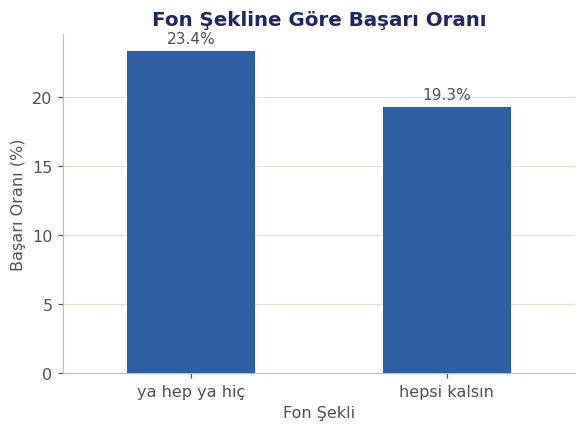

In [62]:
ax = funding_shape_summary["basari_orani"].plot(
    kind="bar",
    figsize=(6, 4),
    color=C_BLUE,
    width=0.5,
    zorder=3,
)

ax.grid(axis="y", color=C_GRID, linewidth=0.8, zorder=0)
ax.bar_label(ax.containers[0], fmt="%.1f%%", padding=3, color=C_MUTED, fontsize=10)

plt.title("Fon Şekline Göre Başarı Oranı")
plt.xlabel("Fon Şekli")
plt.ylabel("Başarı Oranı (%)")
plt.xticks(rotation=0)
plt.show()

Fon şekline göre başarı oranlarında sınırlı bir fark görülmektedir. `Ya hep ya hiç` modelinde başarı oranı `hepsi kalsın` modeline göre bir miktar daha yüksektir. Ancak farkın büyüklüğü diğer bazı kategorik değişkenlerde gözlenen farklılıklara kıyasla daha düşüktür.

In [52]:
region_summary = (
    df_model.groupby("bolge")
    .agg(
        kampanya_sayisi=("basari_durumu", "size"),
        basarili_sayisi=("basari_durumu", lambda x: (x == "başarılı").sum()),
        basari_orani=("basari_durumu", lambda x: (x == "başarılı").mean() * 100)
    )
    .round(2)
    .sort_values("basari_orani", ascending=False)
)

region_summary

,kampanya_sayisi,basarili_sayisi,basari_orani
bolge,,,
marmara,638,193,30.25
akdeniz,102,26,25.49
güneydoğu,46,11,23.91
belirsiz,368,80,21.74
iç anadolu,165,30,18.18
karadeniz,57,9,15.79
ege,136,19,13.97
genel,97,8,8.25
doğu,19,0,0.00


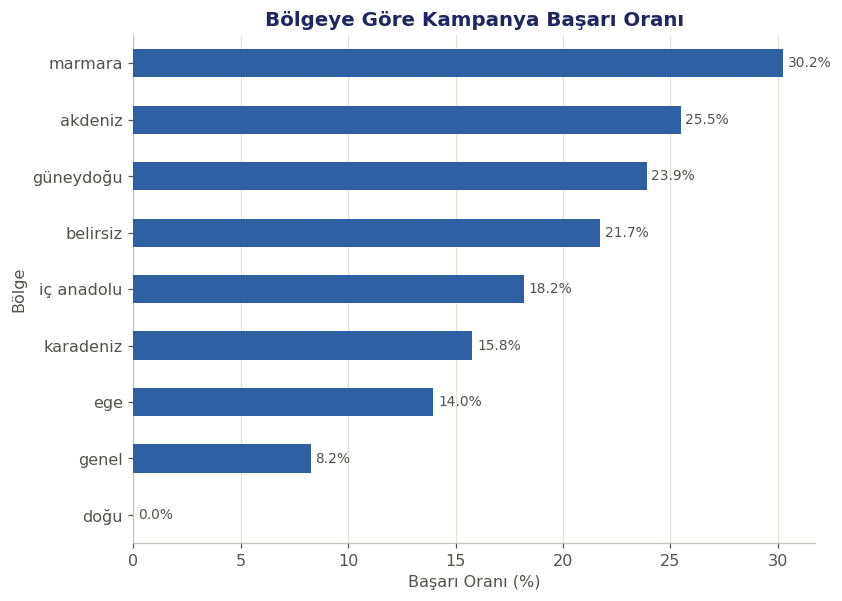

In [64]:
ax = region_summary.sort_values("basari_orani")["basari_orani"].plot(
    kind="barh",
    figsize=(8, 6),
    color=C_BLUE,
    zorder=3,
)

ax.grid(axis="x", color=C_GRID, linewidth=0.8, zorder=0)
ax.bar_label(ax.containers[0], fmt="%.1f%%", padding=3, color=C_MUTED, fontsize=9)

plt.title("Bölgeye Göre Kampanya Başarı Oranı")
plt.xlabel("Başarı Oranı (%)")
plt.ylabel("Bölge")
plt.show()

Bölgelere göre kampanya başarı oranlarında belirgin farklılıklar görülmektedir. Marmara bölgesi %30.25 ile en yüksek başarı oranına sahip büyük örneklemli bölgedir. Akdeniz ve Güneydoğu bölgeleri de genel başarı oranının üzerinde yer almaktadır. Ege, Karadeniz ve İç Anadolu bölgelerinde ise başarı oranları daha düşüktür. Doğu bölgesinde başarı gözlenmemiştir; ancak bu grupta yalnızca 19 kampanya bulunduğu için sonuç dikkatli yorumlanmalıdır.

In [54]:
video_summary = (
    df_model.groupby("tanitim_videosu")
    .agg(
        kampanya_sayisi=("basari_durumu", "size"),
        basarili_sayisi=("basari_durumu", lambda x: (x == "başarılı").sum()),
        basari_orani=("basari_durumu", lambda x: (x == "başarılı").mean() * 100)
    )
    .round(2)
    .sort_values("basari_orani", ascending=False)
)

video_summary

,kampanya_sayisi,basarili_sayisi,basari_orani
tanitim_videosu,,,
var,947,342,36.11
yok,681,34,4.99


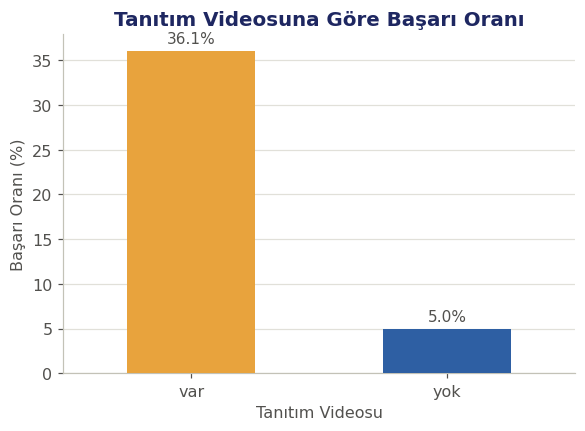

In [66]:
ax = video_summary["basari_orani"].plot(
    kind="bar",
    figsize=(6, 4),
    color=[C_AMBER, C_BLUE],
    width=0.5,
    zorder=3,
)

ax.grid(axis="y", color=C_GRID, linewidth=0.8, zorder=0)
ax.bar_label(ax.containers[0], fmt="%.1f%%", padding=3, color=C_MUTED, fontsize=10)

plt.title("Tanıtım Videosuna Göre Başarı Oranı")
plt.xlabel("Tanıtım Videosu")
plt.ylabel("Başarı Oranı (%)")
plt.xticks(rotation=0)
plt.show()

Tanıtım videosu bulunan kampanyaların başarı oranının, tanıtım videosu bulunmayan kampanyalara göre belirgin şekilde daha yüksek olduğu görülmektedir. Bu fark, `tanitim_videosu` değişkeninin model açısından önemli bilgi taşıyabileceğini düşündürmektedir. Ancak gözlenen ilişki nedensel olarak yorumlanmamalıdır.

In [56]:
for col in ["web_sitesi", "sosyal_medya"]:
    summary = (
        df_model.groupby(col)
        .agg(
            kampanya_sayisi=("basari_durumu", "size"),
            basarili_sayisi=("basari_durumu", lambda x: (x == "başarılı").sum()),
            basari_orani=("basari_durumu", lambda x: (x == "başarılı").mean() * 100)
        )
        .round(2)
        .sort_values("basari_orani", ascending=False)
    )

    print(f"\n--- {col} ---")
    display(summary)


--- web_sitesi ---


,kampanya_sayisi,basarili_sayisi,basari_orani
web_sitesi,,,
var,416,142,34.13
yok,1212,234,19.31



--- sosyal_medya ---


,kampanya_sayisi,basarili_sayisi,basari_orani
sosyal_medya,,,
var,833,249,29.89
yok,795,127,15.97


Web sitesi ve sosyal medya varlığı bulunan kampanyalarda başarı oranlarının daha yüksek olduğu görülmektedir. Web sitesi bulunan kampanyalarda başarı oranı %34.13 iken bulunmayanlarda %19.31; sosyal medya hesabı bulunan kampanyalarda ise %29.89 iken bulunmayanlarda %15.97'dir. Bu değişkenlerin kampanya başarısıyla ilişkili olduğu görülmekle birlikte sonuçlar nedensel olarak yorumlanmamalıdır.

In [57]:
numeric_target_summary = (
    df_model.groupby("basari_durumu")[num_cols]
    .median()
    .T
)

numeric_target_summary

basari_durumu,başarılı,başarısız
kac_proje_destekledi,0.0,0.0
kac_projenin_sahibi,1.0,1.0
kac_proje_takiminda,0.0,0.0
yil,2018.0,2019.0
gun_sayisi,60.0,60.0
video_uzunlugu,70.5,0.0
gorsel_sayisi,5.0,2.0
odul_sayisi,7.0,6.0
ekip_kisi_sayisi,2.0,1.0
sm_sayisi,1.0,0.0


Başarılı ve başarısız kampanyaların sayısal özelliklerinin medyanları karşılaştırıldığında; video uzunluğu, görsel sayısı, ekip büyüklüğü, sosyal medya sayısı ve içerik kelime sayısında belirgin farklılıklar görülmektedir. Başarılı kampanyaların bu değişkenlerde genel olarak daha yüksek medyan değerlere sahip olduğu görülmüştür. Hedef miktarında ise başarılı kampanyaların medyanı daha düşüktür. Bu farklılıklar ilişki göstermekte olup nedensel olarak yorumlanmamaktadır.

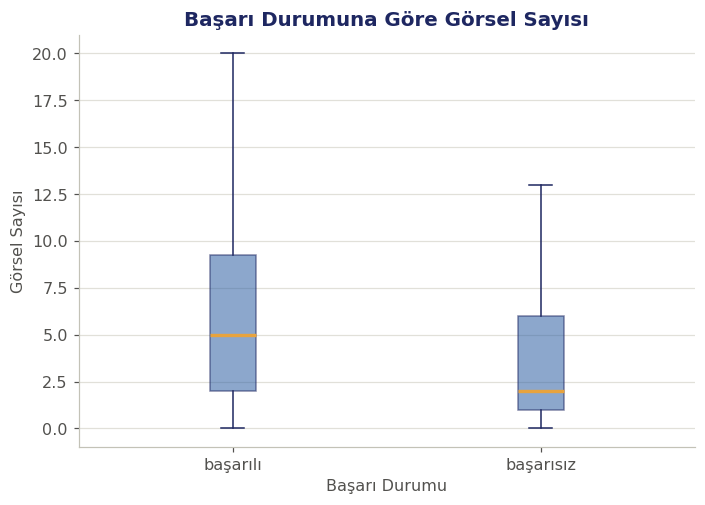

In [69]:
ax = df_model.boxplot(
    column="gorsel_sayisi",
    by="basari_durumu",
    figsize=(7, 5),
    showfliers=False,
    grid=False,
    patch_artist=True,
    boxprops=dict(facecolor=C_BLUE, edgecolor=C_INK, alpha=0.55),
    medianprops=dict(color=C_AMBER, linewidth=2.2),
    whiskerprops=dict(color=C_INK),
    capprops=dict(color=C_INK),
)

ax.grid(axis="y", color=C_GRID, linewidth=0.8, zorder=0)

plt.title("Başarı Durumuna Göre Görsel Sayısı")
plt.suptitle("")
plt.xlabel("Başarı Durumu")
plt.ylabel("Görsel Sayısı")
plt.show()

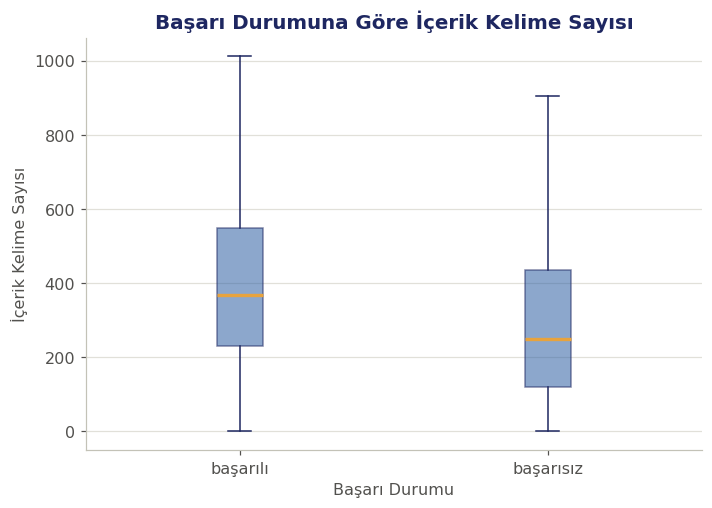

In [70]:
ax = df_model.boxplot(
    column="icerik_kelime_sayisi",
    by="basari_durumu",
    figsize=(7, 5),
    showfliers=False,
    grid=False,
    patch_artist=True,
    boxprops=dict(facecolor=C_BLUE, edgecolor=C_INK, alpha=0.55),
    medianprops=dict(color=C_AMBER, linewidth=2.2),
    whiskerprops=dict(color=C_INK),
    capprops=dict(color=C_INK),
)

ax.grid(axis="y", color=C_GRID, linewidth=0.8, zorder=0)

plt.title("Başarı Durumuna Göre İçerik Kelime Sayısı")
plt.suptitle("")
plt.xlabel("Başarı Durumu")
plt.ylabel("İçerik Kelime Sayısı")
plt.show()

Başarılı kampanyaların hem görsel sayısı hem de içerik kelime sayısı dağılımlarının başarısız kampanyalara göre daha yüksek değerlere kaydığı görülmektedir. Bu bulgu, medyan karşılaştırmalarında gözlenen farklarla uyumludur. Bununla birlikte grupların dağılımları önemli ölçüde örtüştüğünden, bu değişkenlerin tek başına kampanya başarısını belirlediği söylenemez.

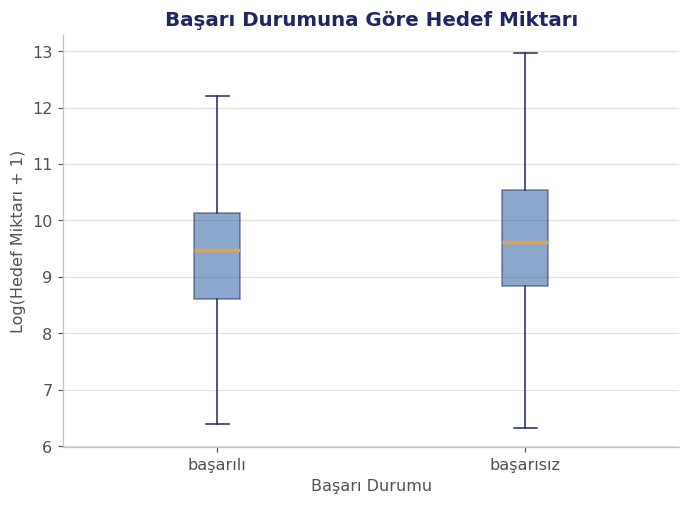

In [71]:
ax = df_model.assign(
    log_hedef_miktari=np.log1p(df_model["hedef_miktari"])
).boxplot(
    column="log_hedef_miktari",
    by="basari_durumu",
    figsize=(7, 5),
    showfliers=False,
    grid=False,
    patch_artist=True,
    boxprops=dict(facecolor=C_BLUE, edgecolor=C_INK, alpha=0.55),
    medianprops=dict(color=C_AMBER, linewidth=2.2),
    whiskerprops=dict(color=C_INK),
    capprops=dict(color=C_INK),
)

ax.grid(axis="y", color=C_GRID, linewidth=0.8, zorder=0)

plt.title("Başarı Durumuna Göre Hedef Miktarı")
plt.suptitle("")
plt.xlabel("Başarı Durumu")
plt.ylabel("Log(Hedef Miktarı + 1)")
plt.show()

Başarısız kampanyaların hedef miktarı dağılımının başarılı kampanyalara göre bir miktar daha yüksek olduğu görülmektedir. Bununla birlikte iki grubun dağılımları büyük ölçüde örtüştüğünden, hedef miktarının tek başına güçlü bir ayırıcı olmadığı görülmektedir. Grafik okunabilirliğini artırmak amacıyla hedef miktarı yalnızca görselleştirme sırasında logaritmik dönüşüme tabi tutulmuştur.

## 10. EDA Sonuçları — 3–5 Temel Bulgu

### Keşif Bulguları

- Tanıtım videosu bulunan kampanyalarda başarı oranı (%36.11), bulunmayanlara (%4.99) göre belirgin şekilde yüksek gözlenmiştir.
- Platform bazında başarı oranları büyük farklılık göstermektedir; büyük örneklemli fongogo'da %26.42 iken crowdfon ve fonbulucu'da %6-7 civarındadır.
- Web sitesi (%34.13'e karşı %19.31) ve sosyal medya hesabı (%29.89'a karşı %15.97) bulunan kampanyalarda başarı oranının daha yüksek olduğu gözlenmiştir.
- Marmara bölgesi (%30.25), genel ortalamanın üzerinde başarı oranına sahip en büyük örneklemli bölge olarak öne çıkmaktadır; düşük örneklemli bazı bölgelerdeki (ör. doğu) oranlar dikkatli yorumlanmalıdır.
- Başarılı kampanyaların görsel sayısı ve içerik kelime sayısı medyanları başarısız kampanyalara göre daha yüksek, hedef miktarı medyanı ise bir miktar daha düşüktür.

Bu bulgular yalnızca bu veri setinde gözlenen ilişkileri yansıtmaktadır; nedensellik iddiası taşımamaktadır.

## 11. Model Öncesi Hazırlık

Modelleme öncesinde özellik (X) ve hedef (y) ayrımı yapılmakta, veri eğitim/test olarak bölünmekte ve kategorik değişkenler One-Hot Encoding ile sayısallaştırılmaktadır.

Kampanya başarı tahmininde ayrımcı bir değişken olmaması için `proje_sahibi_cinsiyet` özellik setinden çıkarılmıştır.

In [61]:
model_df = df_model.drop(columns=["proje_sahibi_cinsiyet"]).copy()

model_df["basari_durumu"] = model_df["basari_durumu"].map({
    "başarısız": 0,
    "başarılı": 1
})

model_df["basari_durumu"].value_counts()

basari_durumu
0    1252
1     376
Name: count, dtype: int64

In [62]:
X = model_df.drop(columns=["basari_durumu"])
y = model_df["basari_durumu"]

print("X shape:", X.shape)
print("y shape:", y.shape)

print("\nHedef dağılımı:")
print(y.value_counts())

X shape: (1628, 21)
y shape: (1628,)

Hedef dağılımı:
basari_durumu
0    1252
1     376
Name: count, dtype: int64


In [63]:
cat_cols_model = X.select_dtypes(include="object").columns.tolist()
num_cols_model = X.select_dtypes(exclude="object").columns.tolist()

print("Kategorik değişkenler:")
print(cat_cols_model)

print("\nSayısal değişkenler:")
print(num_cols_model)

Kategorik değişkenler:
['platform_adi', 'kitle_fonlamasi_turu', 'kategori', 'fon_sekli', 'bolge', 'tanitim_videosu', 'web_sitesi', 'sosyal_medya']

Sayısal değişkenler:
['kac_proje_destekledi', 'kac_projenin_sahibi', 'kac_proje_takiminda', 'yil', 'gun_sayisi', 'video_uzunlugu', 'gorsel_sayisi', 'odul_sayisi', 'ekip_kisi_sayisi', 'sm_sayisi', 'etiket_sayisi', 'icerik_kelime_sayisi', 'hedef_miktari']


In [64]:
from sklearn.model_selection import train_test_split

# Veri dengesiz olduğu için sınıf oranlarını train ve test setlerinde koruyoruz.
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print("X_train:", X_train.shape)
print("X_test:", X_test.shape)

print("\nTrain hedef dağılımı:")
print(y_train.value_counts(normalize=True).round(3))

print("\nTest hedef dağılımı:")
print(y_test.value_counts(normalize=True).round(3))

X_train: (1302, 21)
X_test: (326, 21)

Train hedef dağılımı:
basari_durumu
0    0.769
1    0.231
Name: proportion, dtype: float64

Test hedef dağılımı:
basari_durumu
0    0.77
1    0.23
Name: proportion, dtype: float64


In [ ]:
from sklearn.preprocessing import OneHotEncoder
from sklearn.compose import ColumnTransformer

preprocessor = ColumnTransformer(
    transformers=[
        (
            "cat",
            OneHotEncoder(handle_unknown="ignore", sparse_output=False),
            cat_cols_model
        )
    ],
    remainder="passthrough"
)

In [65]:
# Test setinden bilgi sızmasını önlemek için encoder yalnızca train üzerinde öğreniliyor.
X_train_encoded = preprocessor.fit_transform(X_train)
X_test_encoded = preprocessor.transform(X_test)

print("X_train_encoded:", X_train_encoded.shape)
print("X_test_encoded:", X_test_encoded.shape)

X_train_encoded: (1302, 55)
X_test_encoded: (326, 55)


## 12. Baseline Decision Tree

Decision Tree, başlangıç modeli olarak seçilmiştir. Problem ikili sınıflandırma olduğu için bu algoritma doğrudan uygulanabilmekte, doğrusal olmayan ilişkileri yakalayabilmekte ve karar kurallarının yorumlanabilir olması sayesinde hangi değişkenlerin tahminde etkili olabileceği hakkında hızlı bir fikir vermektedir. Bu nedenle sonraki modellerin karşılaştırılacağı bir baseline olarak kullanılmıştır.

In [66]:
from sklearn.tree import DecisionTreeClassifier

dt_model = DecisionTreeClassifier(
    random_state=42
)

dt_model.fit(X_train_encoded, y_train)

DecisionTreeClassifier(random_state=42)

In [67]:
train_accuracy = dt_model.score(X_train_encoded, y_train)
test_accuracy = dt_model.score(X_test_encoded, y_test)

print("Train Accuracy:", round(train_accuracy, 3))
print("Test Accuracy:", round(test_accuracy, 3))

Train Accuracy: 1.0
Test Accuracy: 0.794


In [68]:
from sklearn.metrics import classification_report, confusion_matrix

y_pred = dt_model.predict(X_test_encoded)

print(classification_report(y_test, y_pred, digits=3))

              precision    recall  f1-score   support

           0      0.868     0.865     0.866       251
           1      0.553     0.560     0.556        75

    accuracy                          0.794       326
   macro avg      0.710     0.712     0.711       326
weighted avg      0.795     0.794     0.795       326



In [69]:
cm = confusion_matrix(y_test, y_pred)
cm

array([[217,  34],
       [ 33,  42]])

## 13. Feature Engineering

In [ ]:
# Tanıtım videosu, web sitesi ve sosyal medya varlığını tek bir sayısal özellikte birleştiriyoruz.
def feature_engineering(dataframe):
    df = dataframe.copy()

    df["dijital_varlik_sayisi"] = (
        (df["tanitim_videosu"] == "var").astype(int) +
        (df["web_sitesi"] == "var").astype(int) +
        (df["sosyal_medya"] == "var").astype(int)
    )

    return df

In [70]:
X_train_fe = feature_engineering(X_train)
X_test_fe = feature_engineering(X_test)

print("Önce:", X_train.shape)
print("Sonra:", X_train_fe.shape)

Önce: (1302, 21)
Sonra: (1302, 22)


In [71]:
cat_cols_fe = X_train_fe.select_dtypes(include="object").columns.tolist()
num_cols_fe = X_train_fe.select_dtypes(exclude="object").columns.tolist()

print("Kategorik:", len(cat_cols_fe))
print("Sayısal:", len(num_cols_fe))
print("\nYeni özellik var mı?:", "dijital_varlik_sayisi" in num_cols_fe)

Kategorik: 8
Sayısal: 14

Yeni özellik var mı?: True


In [ ]:
preprocessor_fe = ColumnTransformer(
    transformers=[
        (
            "cat",
            OneHotEncoder(handle_unknown="ignore", sparse_output=False),
            cat_cols_fe
        )
    ],
    remainder="passthrough"
)

In [72]:
X_train_fe_encoded = preprocessor_fe.fit_transform(X_train_fe)
X_test_fe_encoded = preprocessor_fe.transform(X_test_fe)

print("Train:", X_train_fe_encoded.shape)
print("Test:", X_test_fe_encoded.shape)

Train: (1302, 56)
Test: (326, 56)


In [73]:
dt_model_fe = DecisionTreeClassifier(
    random_state=42
)

dt_model_fe.fit(X_train_fe_encoded, y_train)

train_accuracy_fe = dt_model_fe.score(X_train_fe_encoded, y_train)
test_accuracy_fe = dt_model_fe.score(X_test_fe_encoded, y_test)

print("Train Accuracy:", round(train_accuracy_fe, 3))
print("Test Accuracy:", round(test_accuracy_fe, 3))

Train Accuracy: 1.0
Test Accuracy: 0.801


In [74]:
y_pred_fe = dt_model_fe.predict(X_test_fe_encoded)

print(classification_report(
    y_test,
    y_pred_fe,
    digits=3
))

              precision    recall  f1-score   support

           0      0.875     0.865     0.870       251
           1      0.564     0.587     0.575        75

    accuracy                          0.801       326
   macro avg      0.720     0.726     0.722       326
weighted avg      0.803     0.801     0.802       326



### Feature Engineering Sonucu

Tanıtım videosu, web sitesi ve sosyal medya varlığını bir araya getiren `dijital_varlik_sayisi` özelliği oluşturulmuştur. Yeni özellik eklendikten sonra Decision Tree modeli yeniden eğitilmiş ve test performansında sınırlı ancak tutarlı bir iyileşme gözlenmiştir. Başarılı sınıf için F1-score 0.556'dan 0.575'e, recall ise 0.560'tan 0.587'ye yükselmiştir. Bu nedenle oluşturulan özellik sonraki modelleme aşamalarında korunmuştur.

## 14. Decision Tree Hiperparametre Optimizasyonu

Baseline modeldeki aşırı öğrenmeyi azaltmak amacıyla GridSearchCV ile hiperparametre optimizasyonu yapılmaktadır.

In [75]:
from sklearn.model_selection import GridSearchCV, StratifiedKFold
from sklearn.pipeline import Pipeline

pipeline_fe = Pipeline([
    ("preprocessor", preprocessor_fe),
    ("model", DecisionTreeClassifier(random_state=42))
])

param_grid = {
    "model__max_depth": [3, 4, 5, 6, 8, 10],
    "model__min_samples_split": [2, 10, 20],
    "model__min_samples_leaf": [1, 5, 10],
    "model__class_weight": [None, "balanced"]
}

cv = StratifiedKFold(
    n_splits=5,
    shuffle=True,
    random_state=42
)

grid_search = GridSearchCV(
    estimator=pipeline_fe,
    param_grid=param_grid,
    scoring="f1",
    cv=cv,
    n_jobs=-1
)

grid_search.fit(X_train_fe, y_train)

c:\ProgramData\anaconda3\Lib\site-packages\sklearn\compose\_column_transformer.py:1667: FutureWarning: 
The format of the columns of the 'remainder' transformer in ColumnTransformer.transformers_ will change in version 1.7 to match the format of the other transformers.
At the moment the remainder columns are stored as indices (of type int). With the same ColumnTransformer configuration, in the future they will be stored as column names (of type str).
To use the new behavior now and suppress this warning, use ColumnTransformer(force_int_remainder_cols=False).

  warnings.warn(


GridSearchCV(cv=StratifiedKFold(n_splits=5, random_state=42, shuffle=True),
             estimator=Pipeline(steps=[('preprocessor',
                                        ColumnTransformer(remainder='passthrough',
                                                          transformers=[('cat',
                                                                         OneHotEncoder(handle_unknown='ignore',
                                                                                       sparse_output=False),
                                                                         ['platform_adi',
                                                                          'kitle_fonlamasi_turu',
                                                                          'kategori',
                                                                          'fon_sekli',
                                                                          'bolge',
                                                                          'tanitim_videosu',
                                                                          'web_sitesi',
                                                                          'sosyal_medya'])])),
                                       ('model',
                                        DecisionTreeClassifier(random_state=42))]),
             n_jobs=-1,
             param_grid={'model__class_weight': [None, 'balanced'],
                         'model__max_depth': [3, 4, 5, 6, 8, 10],
                         'model__min_samples_leaf': [1, 5, 10],
                         'model__min_samples_split': [2, 10, 20]},
             scoring='f1')

In [76]:
print("En iyi parametreler:")
print(grid_search.best_params_)

print("\nEn iyi CV F1:")
print(round(grid_search.best_score_, 3))

En iyi parametreler:
{'model__class_weight': 'balanced', 'model__max_depth': 8, 'model__min_samples_leaf': 5, 'model__min_samples_split': 2}

En iyi CV F1:
0.61


In [77]:
best_model = grid_search.best_estimator_

y_train_pred_tuned = best_model.predict(X_train_fe)
y_test_pred_tuned = best_model.predict(X_test_fe)

print(
    "Train Accuracy:",
    round(best_model.score(X_train_fe, y_train), 3)
)

print(
    "Test Accuracy:",
    round(best_model.score(X_test_fe, y_test), 3)
)

Train Accuracy: 0.828
Test Accuracy: 0.767


In [78]:
print(
    classification_report(
        y_test,
        y_test_pred_tuned,
        digits=3
    )
)

              precision    recall  f1-score   support

           0      0.907     0.777     0.837       251
           1      0.495     0.733     0.591        75

    accuracy                          0.767       326
   macro avg      0.701     0.755     0.714       326
weighted avg      0.812     0.767     0.780       326



In [79]:
cm_tuned = confusion_matrix(y_test, y_test_pred_tuned)
cm_tuned

array([[195,  56],
       [ 20,  55]])

### Hiperparametre Optimizasyonu Sonucu

GridSearchCV sonucunda `class_weight='balanced'`, `max_depth=8`,
`min_samples_leaf=5` ve `min_samples_split=2` parametreleri seçilmiştir.

Optimizasyon sonrasında eğitim doğruluğu %100'den %82.8'e düşmüş ve
baseline modeldeki aşırı öğrenme önemli ölçüde azaltılmıştır. Test
doğruluğu %76.7 olarak gerçekleşirken, başarılı kampanyaların recall
değeri %73.3'e ve F1-score değeri %59.1'e yükselmiştir.

Bu sonuç, modelin genel doğruluktan bir miktar ödün vererek azınlık
sınıfı olan başarılı kampanyaları daha yüksek oranda yakalayabildiğini
göstermektedir.

In [80]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, balanced_accuracy_score

comparison = pd.DataFrame({
    "Model": [
        "Baseline Decision Tree",
        "Feature Engineering",
        "Feature Engineering + Tuning"
    ],
    "Accuracy": [
        accuracy_score(y_test, y_pred),
        accuracy_score(y_test, y_pred_fe),
        accuracy_score(y_test, y_test_pred_tuned)
    ],
    "Precision": [
        precision_score(y_test, y_pred),
        precision_score(y_test, y_pred_fe),
        precision_score(y_test, y_test_pred_tuned)
    ],
    "Recall": [
        recall_score(y_test, y_pred),
        recall_score(y_test, y_pred_fe),
        recall_score(y_test, y_test_pred_tuned)
    ],
    "F1": [
        f1_score(y_test, y_pred),
        f1_score(y_test, y_pred_fe),
        f1_score(y_test, y_test_pred_tuned)
    ],
    "Balanced Accuracy": [
        balanced_accuracy_score(y_test, y_pred),
        balanced_accuracy_score(y_test, y_pred_fe),
        balanced_accuracy_score(y_test, y_test_pred_tuned)
    ]
}).round(3)

comparison

,Model,Accuracy,Precision,Recall,F1,Balanced Accuracy
0,Baseline Decision Tree,0.794,0.553,0.560,0.556,0.712
1,Feature Engineering,0.801,0.564,0.587,0.575,0.726
2,Feature Engineering + Tuning,0.767,0.495,0.733,0.591,0.755


### Decision Tree Modellerinin Karşılaştırılması

Üç Decision Tree modeli karşılaştırıldığında Feature Engineering + Tuning modelinin test accuracy değeri diğer modellere göre daha düşük olmasına rağmen, dengesiz veri yapısı açısından daha anlamlı olan recall, F1-score ve balanced accuracy metriklerinde daha iyi sonuç verdiği görülmüştür.

Başarılı kampanyalar için recall değeri %58.7'den %73.3'e yükselirken, F1-score 0.591 ve balanced accuracy 0.755 olarak gerçekleşmiştir. Ayrıca eğitim doğruluğunun %100'den %82.8'e düşmesi, başlangıç modelindeki aşırı öğrenmenin önemli ölçüde azaltıldığını göstermektedir.

Bu aşamada Decision Tree modelleri arasında en iyi sonucu, Feature Engineering ve hiperparametre optimizasyonu uygulanmış model vermiştir. Nihai model seçimi, ileride Random Forest ve XGBoost ile yapılacak karşılaştırmadan sonra belirlenecektir.

## 15. Random Forest

In [81]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.pipeline import Pipeline

rf_pipeline = Pipeline([
    ("preprocessor", preprocessor_fe),
    ("model", RandomForestClassifier(
        n_estimators=300,
        class_weight="balanced",
        random_state=42,
        n_jobs=-1
    ))
])

rf_pipeline.fit(X_train_fe, y_train)

c:\ProgramData\anaconda3\Lib\site-packages\sklearn\compose\_column_transformer.py:1667: FutureWarning: 
The format of the columns of the 'remainder' transformer in ColumnTransformer.transformers_ will change in version 1.7 to match the format of the other transformers.
At the moment the remainder columns are stored as indices (of type int). With the same ColumnTransformer configuration, in the future they will be stored as column names (of type str).
To use the new behavior now and suppress this warning, use ColumnTransformer(force_int_remainder_cols=False).

  warnings.warn(


Pipeline(steps=[('preprocessor',
                 ColumnTransformer(remainder='passthrough',
                                   transformers=[('cat',
                                                  OneHotEncoder(handle_unknown='ignore',
                                                                sparse_output=False),
                                                  ['platform_adi',
                                                   'kitle_fonlamasi_turu',
                                                   'kategori', 'fon_sekli',
                                                   'bolge', 'tanitim_videosu',
                                                   'web_sitesi',
                                                   'sosyal_medya'])])),
                ('model',
                 RandomForestClassifier(class_weight='balanced',
                                        n_estimators=300, n_jobs=-1,
                                        random_state=42))])

In [82]:
rf_train_acc = rf_pipeline.score(X_train_fe, y_train)
rf_test_acc = rf_pipeline.score(X_test_fe, y_test)

y_pred_rf = rf_pipeline.predict(X_test_fe)

print("Train Accuracy:", round(rf_train_acc, 3))
print("Test Accuracy:", round(rf_test_acc, 3))

print("\nClassification Report:")
print(classification_report(
    y_test,
    y_pred_rf,
    digits=3
))

Train Accuracy: 1.0
Test Accuracy: 0.865

Classification Report:
              precision    recall  f1-score   support

           0      0.876     0.960     0.916       251
           1      0.804     0.547     0.651        75

    accuracy                          0.865       326
   macro avg      0.840     0.753     0.784       326
weighted avg      0.860     0.865     0.855       326



### Random Forest Sonucu

Random Forest modeli test verisinde %86.5 accuracy ve başarılı sınıf için 0.651 F1-score elde etmiştir. Başarılı kampanyalar için precision 0.804 ile yüksek seviyeye çıkarken recall 0.547 olarak gerçekleşmiştir.

Random Forest, Decision Tree modellerine göre genel doğruluk ve F1-score açısından daha güçlü sonuç vermiştir. Bununla birlikte başarılı kampanyaları yakalama oranı, sınıf ağırlıklı Decision Tree modeline göre daha düşüktür. Bu nedenle modeller yalnızca accuracy üzerinden değil, precision-recall dengesi dikkate alınarak karşılaştırılacaktır.

## 16. XGBoost

In [83]:
scale_pos_weight = (
    (y_train == 0).sum() /
    (y_train == 1).sum()
)

print("scale_pos_weight:", round(scale_pos_weight, 3))

scale_pos_weight: 3.326


In [84]:
from xgboost import XGBClassifier

xgb_pipeline = Pipeline([
    ("preprocessor", preprocessor_fe),
    ("model", XGBClassifier(
        n_estimators=300,
        max_depth=4,
        learning_rate=0.05,
        subsample=0.8,
        colsample_bytree=0.8,
        scale_pos_weight=scale_pos_weight,
        eval_metric="logloss",
        random_state=42,
        n_jobs=-1
    ))
])

xgb_pipeline.fit(X_train_fe, y_train)

c:\ProgramData\anaconda3\Lib\site-packages\sklearn\compose\_column_transformer.py:1667: FutureWarning: 
The format of the columns of the 'remainder' transformer in ColumnTransformer.transformers_ will change in version 1.7 to match the format of the other transformers.
At the moment the remainder columns are stored as indices (of type int). With the same ColumnTransformer configuration, in the future they will be stored as column names (of type str).
To use the new behavior now and suppress this warning, use ColumnTransformer(force_int_remainder_cols=False).

  warnings.warn(


Pipeline(steps=[('preprocessor',
                 ColumnTransformer(remainder='passthrough',
                                   transformers=[('cat',
                                                  OneHotEncoder(handle_unknown='ignore',
                                                                sparse_output=False),
                                                  ['platform_adi',
                                                   'kitle_fonlamasi_turu',
                                                   'kategori', 'fon_sekli',
                                                   'bolge', 'tanitim_videosu',
                                                   'web_sitesi',
                                                   'sosyal_medya'])])),
                ('model',
                 XGBClassifier(base_score=None, booster=None, callbacks=None,
                               colsampl...
                               feature_types=None, feature_weights=None,
                               gamma=None, grow_policy=None,
                               importance_type=None,
                               interaction_constraints=None, learning_rate=0.05,
                               max_bin=None, max_cat_threshold=None,
                               max_cat_to_onehot=None, max_delta_step=None,
                               max_depth=4, max_leaves=None,
                               min_child_weight=None, missing=nan,
                               monotone_constraints=None, multi_strategy=None,
                               n_estimators=300, n_jobs=-1,
                               num_parallel_tree=None, ...))])

In [85]:
y_pred_xgb = xgb_pipeline.predict(X_test_fe)

print(
    "Train Accuracy:",
    round(xgb_pipeline.score(X_train_fe, y_train), 3)
)

print(
    "Test Accuracy:",
    round(xgb_pipeline.score(X_test_fe, y_test), 3)
)

print("\nClassification Report:")
print(
    classification_report(
        y_test,
        y_pred_xgb,
        digits=3
    )
)

Train Accuracy: 0.975
Test Accuracy: 0.828

Classification Report:
              precision    recall  f1-score   support

           0      0.918     0.853     0.884       251
           1      0.602     0.747     0.667        75

    accuracy                          0.828       326
   macro avg      0.760     0.800     0.775       326
weighted avg      0.846     0.828     0.834       326



In [86]:
comparison.loc[len(comparison)] = {
    "Model": "XGBoost",
    "Accuracy": accuracy_score(y_test, y_pred_xgb),
    "Precision": precision_score(y_test, y_pred_xgb),
    "Recall": recall_score(y_test, y_pred_xgb),
    "F1": f1_score(y_test, y_pred_xgb),
    "Balanced Accuracy": balanced_accuracy_score(y_test, y_pred_xgb)
}

comparison.round(3)

,Model,Accuracy,Precision,Recall,F1,Balanced Accuracy
0,Baseline Decision Tree,0.794,0.553,0.560,0.556,0.712
1,Feature Engineering,0.801,0.564,0.587,0.575,0.726
2,Feature Engineering + Tuning,0.767,0.495,0.733,0.591,0.755
3,XGBoost,0.828,0.602,0.747,0.667,0.800


In [87]:
comparison.loc[len(comparison)] = {
    "Model": "Random Forest",
    "Accuracy": accuracy_score(y_test, y_pred_rf),
    "Precision": precision_score(y_test, y_pred_rf),
    "Recall": recall_score(y_test, y_pred_rf),
    "F1": f1_score(y_test, y_pred_rf),
    "Balanced Accuracy": balanced_accuracy_score(y_test, y_pred_rf)
}

comparison.round(3)

,Model,Accuracy,Precision,Recall,F1,Balanced Accuracy
0,Baseline Decision Tree,0.794,0.553,0.560,0.556,0.712
1,Feature Engineering,0.801,0.564,0.587,0.575,0.726
2,Feature Engineering + Tuning,0.767,0.495,0.733,0.591,0.755
3,XGBoost,0.828,0.602,0.747,0.667,0.800
4,Random Forest,0.865,0.804,0.547,0.651,0.753


In [88]:
from sklearn.model_selection import GridSearchCV, StratifiedKFold

xgb_tune_pipeline = Pipeline([
    ("preprocessor", preprocessor_fe),
    ("model", XGBClassifier(
        eval_metric="logloss",
        random_state=42,
        n_jobs=-1
    ))
])

xgb_param_grid = {
    "model__n_estimators": [150, 300],
    "model__max_depth": [2, 3, 4],
    "model__learning_rate": [0.03, 0.05, 0.1],
    "model__min_child_weight": [1, 3],
    "model__subsample": [0.8, 1.0],
    "model__colsample_bytree": [0.8, 1.0],
    "model__scale_pos_weight": [1, scale_pos_weight]
}

cv = StratifiedKFold(
    n_splits=5,
    shuffle=True,
    random_state=42
)

xgb_grid = GridSearchCV(
    estimator=xgb_tune_pipeline,
    param_grid=xgb_param_grid,
    scoring="f1",
    cv=cv,
    n_jobs=-1
)

xgb_grid.fit(X_train_fe, y_train)

c:\ProgramData\anaconda3\Lib\site-packages\sklearn\compose\_column_transformer.py:1667: FutureWarning: 
The format of the columns of the 'remainder' transformer in ColumnTransformer.transformers_ will change in version 1.7 to match the format of the other transformers.
At the moment the remainder columns are stored as indices (of type int). With the same ColumnTransformer configuration, in the future they will be stored as column names (of type str).
To use the new behavior now and suppress this warning, use ColumnTransformer(force_int_remainder_cols=False).

  warnings.warn(


GridSearchCV(cv=StratifiedKFold(n_splits=5, random_state=42, shuffle=True),
             estimator=Pipeline(steps=[('preprocessor',
                                        ColumnTransformer(remainder='passthrough',
                                                          transformers=[('cat',
                                                                         OneHotEncoder(handle_unknown='ignore',
                                                                                       sparse_output=False),
                                                                         ['platform_adi',
                                                                          'kitle_fonlamasi_turu',
                                                                          'kategori',
                                                                          'fon_sekli',
                                                                          'bolge',
                                                                          'tanitim_videosu',
                                                                          'web_sitesi',
                                                                          'sosyal_medy...
                                                      n_estimators=None,
                                                      n_jobs=-1,
                                                      num_parallel_tree=None, ...))]),
             n_jobs=-1,
             param_grid={'model__colsample_bytree': [0.8, 1.0],
                         'model__learning_rate': [0.03, 0.05, 0.1],
                         'model__max_depth': [2, 3, 4],
                         'model__min_child_weight': [1, 3],
                         'model__n_estimators': [150, 300],
                         'model__scale_pos_weight': [1,
                                                     np.float64(3.3255813953488373)],
                         'model__subsample': [0.8, 1.0]},
             scoring='f1')

In [89]:
print("En iyi parametreler:")
print(xgb_grid.best_params_)

print("\nEn iyi CV F1:")
print(round(xgb_grid.best_score_, 3))

En iyi parametreler:
{'model__colsample_bytree': 1.0, 'model__learning_rate': 0.1, 'model__max_depth': 4, 'model__min_child_weight': 3, 'model__n_estimators': 150, 'model__scale_pos_weight': 1, 'model__subsample': 1.0}

En iyi CV F1:
0.687


In [90]:
best_xgb = xgb_grid.best_estimator_

y_pred_xgb_tuned = best_xgb.predict(X_test_fe)

print(
    "Train Accuracy:",
    round(best_xgb.score(X_train_fe, y_train), 3)
)

print(
    "Test Accuracy:",
    round(best_xgb.score(X_test_fe, y_test), 3)
)

print("\nClassification Report:")
print(
    classification_report(
        y_test,
        y_pred_xgb_tuned,
        digits=3
    )
)

Train Accuracy: 0.956
Test Accuracy: 0.837

Classification Report:
              precision    recall  f1-score   support

           0      0.881     0.912     0.896       251
           1      0.667     0.587     0.624        75

    accuracy                          0.837       326
   macro avg      0.774     0.750     0.760       326
weighted avg      0.832     0.837     0.834       326



In [91]:
print(
    "Balanced Accuracy:",
    round(
        balanced_accuracy_score(
            y_test,
            y_pred_xgb_tuned
        ),
        3
    )
)

cm_xgb_tuned = confusion_matrix(
    y_test,
    y_pred_xgb_tuned
)

cm_xgb_tuned

Balanced Accuracy: 0.75


array([[229,  22],
       [ 31,  44]])

## 17. Modellerin Karşılaştırılması

Bu noktaya kadar test seti üzerinde karşılaştırılan modeller (Baseline Decision Tree, Feature Engineering uygulanmış Decision Tree, hiperparametre optimizasyonlu Decision Tree, XGBoost ve Random Forest) yukarıdaki `comparison` tablosunda özetlenmiştir.

Random Forest ve XGBoost, Decision Tree tabanlı modellere göre genel olarak daha güçlü test performansı sağlamıştır. Modeller arasındaki nihai seçim, tek bir test seti sonucuna değil, bir sonraki bölümde yapılan cross-validation karşılaştırmasına dayandırılmaktadır.

## 18. Cross-Validation Sonuçları

In [92]:
from sklearn.model_selection import cross_validate

models_cv = {
    "Random Forest": rf_pipeline,
    "XGBoost": xgb_pipeline,
    "Tuned XGBoost": best_xgb
}

cv_results = []

for name, model in models_cv.items():
    scores = cross_validate(
        model,
        X_train_fe,
        y_train,
        cv=cv,
        scoring={
            "f1": "f1",
            "recall": "recall",
            "precision": "precision",
            "balanced_accuracy": "balanced_accuracy"
        },
        n_jobs=-1
    )

    cv_results.append({
        "Model": name,
        "CV F1": scores["test_f1"].mean(),
        "CV Recall": scores["test_recall"].mean(),
        "CV Precision": scores["test_precision"].mean(),
        "CV Balanced Accuracy": scores["test_balanced_accuracy"].mean()
    })

cv_comparison = pd.DataFrame(cv_results).round(3)
cv_comparison

,Model,CV F1,CV Recall,CV Precision,CV Balanced Accuracy
0,Random Forest,0.607,0.489,0.819,0.727
1,XGBoost,0.679,0.741,0.629,0.804
2,Tuned XGBoost,0.687,0.621,0.772,0.782


### Gelişmiş Modellerin Çapraz Doğrulama ile Karşılaştırılması

Random Forest, XGBoost ve hiperparametre optimizasyonu uygulanmış XGBoost modelleri 5 katlı stratified cross-validation ile karşılaştırılmıştır.

Random Forest modeli yüksek precision göstermesine rağmen başarılı kampanyaları yakalama oranı daha düşük kalmıştır. Standart XGBoost modeli 0.741 recall ve 0.804 balanced accuracy ile başarılı kampanyaları yakalama açısından en güçlü sonucu vermiştir.

Hiperparametre optimizasyonu uygulanmış XGBoost modeli ise 0.687 ile en yüksek ortalama F1-score değerini elde etmiştir. Model seçiminde önceden belirlenen temel optimizasyon metriği F1-score olduğundan nihai ana model olarak Tuned XGBoost seçilmiştir.

Bununla birlikte standart XGBoost modeli daha yüksek recall ve balanced accuracy sağladığından, başarılı kampanyaları kaçırma maliyetinin daha önemli olduğu kullanım senaryolarında alternatif bir model olarak değerlendirilebilir.

## 19. Karar Eşiği Optimizasyonu

In [ ]:
from sklearn.model_selection import cross_val_predict

y_train_proba_cv = cross_val_predict(
    best_xgb,
    X_train_fe,
    y_train,
    cv=cv,
    method="predict_proba",
    n_jobs=-1
)[:, 1]

In [93]:
from sklearn.metrics import precision_recall_curve
import numpy as np

# Optimize edilen eşik yalnızca eğitim verisindeki CV tahminlerinden belirleniyor.
precision, recall, thresholds = precision_recall_curve(
    y_train,
    y_train_proba_cv
)

f1_scores = (
    2 * precision[:-1] * recall[:-1] /
    (precision[:-1] + recall[:-1] + 1e-10)
)

best_index = np.argmax(f1_scores)
best_threshold = thresholds[best_index]

print("En iyi threshold:", round(best_threshold, 3))
print("CV Precision:", round(precision[best_index], 3))
print("CV Recall:", round(recall[best_index], 3))
print("CV F1:", round(f1_scores[best_index], 3))

En iyi threshold: 0.451
CV Precision: 0.739
CV Recall: 0.668
CV F1: 0.702


In [94]:
y_test_proba = best_xgb.predict_proba(X_test_fe)[:, 1]

y_pred_threshold = (
    y_test_proba >= best_threshold
).astype(int)

print(
    classification_report(
        y_test,
        y_pred_threshold,
        digits=3
    )
)

print(
    "Balanced Accuracy:",
    round(
        balanced_accuracy_score(
            y_test,
            y_pred_threshold
        ),
        3
    )
)

              precision    recall  f1-score   support

           0      0.894     0.904     0.899       251
           1      0.667     0.640     0.653        75

    accuracy                          0.844       326
   macro avg      0.780     0.772     0.776       326
weighted avg      0.841     0.844     0.842       326

Balanced Accuracy: 0.772


In [95]:
cm_threshold = confusion_matrix(
    y_test,
    y_pred_threshold
)

cm_threshold

array([[227,  24],
       [ 27,  48]])

### Karar Eşiği Optimizasyonu

Varsayılan sınıflandırma eşiği olan 0.50 yerine, eğitim verisi üzerinde
cross-validation ile elde edilen olasılık tahminleri kullanılarak F1-score'u
maksimize eden karar eşiği belirlenmiştir.

Optimum eşik 0.451 olarak bulunmuş ve cross-validation F1-score değeri
0.687'den 0.702'ye yükselmiştir.

Bu eşik test verisine uygulandığında accuracy 0.844, başarılı sınıf için
precision 0.667, recall 0.640 ve F1-score 0.653 olarak elde edilmiştir.
Balanced accuracy değeri ise 0.772'ye yükselmiştir.

Sonuç olarak karar eşiğinin optimize edilmesi, varsayılan 0.50 eşiğine göre
başarılı kampanyaları yakalama oranını ve sınıflar arasındaki performans
dengesini iyileştirmiştir.

## 20. Final Model Performansı

Final model olarak seçilen Tuned XGBoost, cross-validation ile belirlenen %45.1 karar eşiği kullanıldığında test setinde %84.4 accuracy, başarılı sınıf için 0.667 precision, 0.640 recall ve 0.653 F1-score elde etmiştir. Balanced accuracy değeri 0.772'dir.

Modelin eğitim verisindeki accuracy değeri (%95.6), varsayılan 0.50 eşiğindeki test accuracy değerine (%83.7) göre daha yüksektir. Bu fark bir miktar aşırı öğrenmeye işaret etmektedir; ancak baseline Decision Tree modelinde gözlenen %100 - %79.4 farkına kıyasla oldukça sınırlıdır.

Veri seti dengesiz olduğu (%76.9 başarısız, %23.1 başarılı) için model değerlendirmesinde yalnızca accuracy'ye güvenilmemiş; precision, recall, F1-score ve balanced accuracy birlikte değerlendirilmiştir.

## 21. Feature Importance

In [96]:
feature_names = best_xgb.named_steps[
    "preprocessor"
].get_feature_names_out()

importances = best_xgb.named_steps[
    "model"
].feature_importances_

feature_importance = pd.DataFrame({
    "feature": feature_names,
    "importance": importances
}).sort_values(
    "importance",
    ascending=False
)

feature_importance.head(15)

,feature,importance
36,cat__tanitim_videosu_var,0.222298
28,cat__bolge_belirsiz,0.067038
3,cat__platform_adi_fonbulucu,0.065360
42,remainder__kac_proje_destekledi,0.060296
0,cat__platform_adi_arıkovanı,0.058251
47,remainder__video_uzunlugu,0.048362
45,remainder__yil,0.044177
21,cat__kategori_teknoloji,0.031906
49,remainder__odul_sayisi,0.030662
30,cat__bolge_ege,0.026218


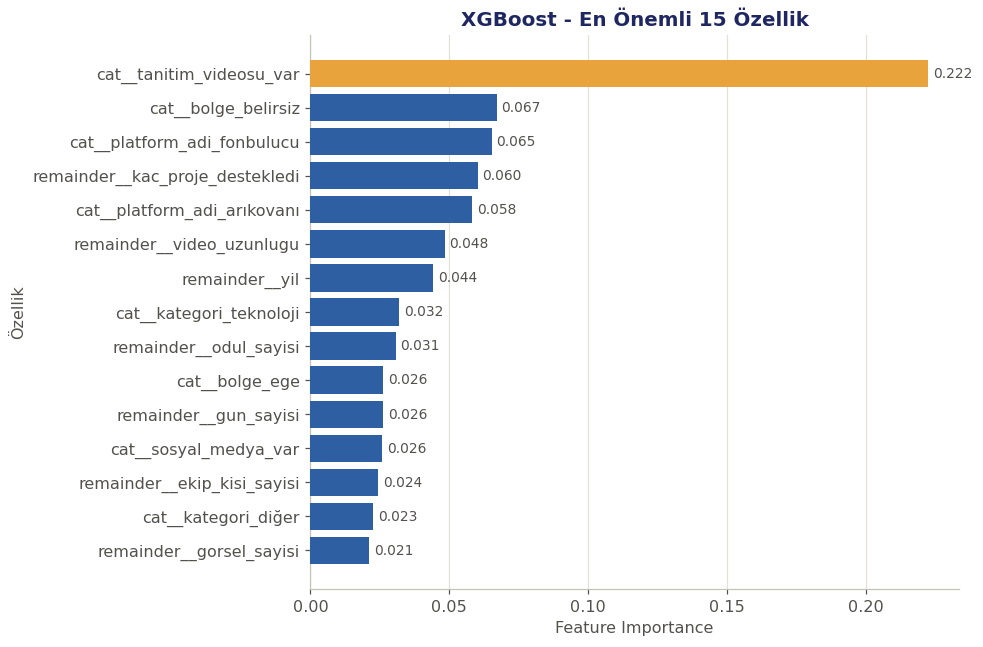

In [112]:
top_features = feature_importance.head(15).sort_values(
    "importance"
)

colors = [C_BLUE] * (len(top_features) - 1) + [C_AMBER]

fig, ax = plt.subplots(figsize=(9, 6))

ax.barh(
    top_features["feature"],
    top_features["importance"],
    color=colors,
    zorder=3,
)

ax.grid(axis="x", color=C_GRID, linewidth=0.8, zorder=0)
ax.bar_label(ax.containers[0], fmt="%.3f", padding=3, color=C_MUTED, fontsize=9)

plt.title("XGBoost - En Önemli 15 Özellik")
plt.xlabel("Feature Importance")
plt.ylabel("Özellik")
plt.tight_layout()
plt.show()

In [98]:
feature_importance[
    feature_importance["feature"].str.contains("dijital_varlik")
]

,feature,importance
55,remainder__dijital_varlik_sayisi,0.021164


In [99]:
feature_importance = feature_importance.reset_index(drop=True)
feature_importance["rank"] = feature_importance.index + 1

feature_importance[
    feature_importance["feature"].str.contains("dijital_varlik")
]

,feature,importance,rank
15,remainder__dijital_varlik_sayisi,0.021164,16


### Özellik Önem Analizi

Final XGBoost modelinin özellik önem skorları incelendiğinde, `tanitim_videosu_var`
değişkeninin açık ara en yüksek önem değerine sahip olduğu görülmüştür. Platform,
bölge, proje sahibinin geçmiş destek deneyimi, video uzunluğu, yıl, kategori ve
ödül sayısı gibi değişkenler de model kararlarında öne çıkmıştır.

Özellik önem skorları değişkenlerin model tahminine katkısını göstermektedir;
bu değerler değişkenlerin kampanya başarısı üzerinde olumlu veya nedensel bir
etkiye sahip olduğunu göstermemektedir.

In [ ]:
xgb_no_fe = Pipeline([
    ("preprocessor", preprocessor),
    ("model", XGBClassifier(
        n_estimators=300,
        max_depth=4,
        learning_rate=0.05,
        subsample=0.8,
        colsample_bytree=0.8,
        scale_pos_weight=scale_pos_weight,
        eval_metric="logloss",
        random_state=42,
        n_jobs=-1
    ))
])

In [100]:
ablation_results = []

for name, model, X_data in [
    ("Feature Engineering Yok", xgb_no_fe, X_train),
    ("Feature Engineering Var", xgb_pipeline, X_train_fe)
]:
    scores = cross_validate(
        model,
        X_data,
        y_train,
        cv=cv,
        scoring={
            "f1": "f1",
            "balanced_accuracy": "balanced_accuracy"
        },
        n_jobs=-1
    )

    ablation_results.append({
        "Model": name,
        "CV F1": scores["test_f1"].mean(),
        "CV Balanced Accuracy": scores["test_balanced_accuracy"].mean()
    })

pd.DataFrame(ablation_results).round(3)

,Model,CV F1,CV Balanced Accuracy
0,Feature Engineering Yok,0.673,0.798
1,Feature Engineering Var,0.679,0.804


### Feature Engineering Doğrulaması

Oluşturulan `dijital_varlik_sayisi` özelliğinin katkısını değerlendirmek amacıyla
feature engineering uygulanmış ve uygulanmamış XGBoost modelleri aynı
cross-validation yapısı altında karşılaştırılmıştır.

Feature engineering olmadan ortalama F1-score 0.673 ve balanced accuracy 0.798
iken, yeni özellik eklendiğinde bu değerler sırasıyla 0.679 ve 0.804'e
yükselmiştir.

İyileşme sınırlı olmakla birlikte her iki performans ölçütünde de aynı yönde
olduğu için `dijital_varlik_sayisi` özelliğinin final modelde korunmasına karar
verilmiştir.

## 22. SHAP ile Model Açıklanabilirliği

In [101]:
import shap

print("SHAP version:", shap.__version__)

SHAP version: 0.52.0


In [102]:
final_preprocessor = best_xgb.named_steps["preprocessor"]
final_xgb_model = best_xgb.named_steps["model"]

X_test_shap_array = final_preprocessor.transform(X_test_fe)

feature_names = final_preprocessor.get_feature_names_out()

X_test_shap = pd.DataFrame(
    X_test_shap_array,
    columns=feature_names,
    index=X_test_fe.index
)

print(X_test_shap.shape)
X_test_shap.head()

(326, 56)


,cat__platform_adi_arıkovanı,cat__platform_adi_buluşum,cat__platform_adi_crowdfon,cat__platform_adi_fonbulucu,cat__platform_adi_fongogo,cat__platform_adi_ideanest,cat__kitle_fonlamasi_turu_bağış,cat__kitle_fonlamasi_turu_ödül,cat__kategori_dans-performans,cat__kategori_diğer,cat__kategori_eğitim,cat__kategori_film-video-fotoğraf,cat__kategori_gıda-yeme-içme,cat__kategori_hayvanlar,cat__kategori_kültür-sanat,cat__kategori_moda,cat__kategori_müzik,cat__kategori_sağlık-güzellik,cat__kategori_sosyal sorumluluk,cat__kategori_spor,cat__kategori_tasarım,cat__kategori_teknoloji,cat__kategori_turizm,cat__kategori_yayıncılık,cat__kategori_çevre,cat__fon_sekli_hepsi kalsın,cat__fon_sekli_ya hep ya hiç,cat__bolge_akdeniz,cat__bolge_belirsiz,cat__bolge_doğu,cat__bolge_ege,cat__bolge_genel,cat__bolge_güneydoğu,cat__bolge_iç anadolu,cat__bolge_karadeniz,cat__bolge_marmara,cat__tanitim_videosu_var,cat__tanitim_videosu_yok,cat__web_sitesi_var,cat__web_sitesi_yok,cat__sosyal_medya_var,cat__sosyal_medya_yok,remainder__kac_proje_destekledi,remainder__kac_projenin_sahibi,remainder__kac_proje_takiminda,remainder__yil,remainder__gun_sayisi,remainder__video_uzunlugu,remainder__gorsel_sayisi,remainder__odul_sayisi,remainder__ekip_kisi_sayisi,remainder__sm_sayisi,remainder__etiket_sayisi,remainder__icerik_kelime_sayisi,remainder__hedef_miktari,remainder__dijital_varlik_sayisi
683,0.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,1.0,0.0,1.0,0.0,1.0,0.0,3.0,7.0,0.0,2019.0,42.0,144.0,1.0,9.0,1.0,3.0,5.0,126.0,6000.0,3.0
665,0.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0,1.0,0.0,0.0,1.0,0.0,2018.0,90.0,58.0,11.0,9.0,1.0,3.0,5.0,852.0,85600.0,3.0
1405,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0,1.0,0.0,1.0,0.0,2015.0,60.0,0.0,1.0,4.0,1.0,0.0,0.0,115.0,50000.0,0.0
293,0.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0,1.0,0.0,1.0,0.0,1.0,0.0,2020.0,60.0,0.0,1.0,4.0,1.0,0.0,3.0,224.0,70000.0,0.0
1426,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0,1.0,0.0,1.0,0.0,2015.0,60.0,0.0,1.0,4.0,1.0,0.0,0.0,115.0,50000.0,0.0


In [ ]:
explainer = shap.TreeExplainer(final_xgb_model)

shap_values = explainer.shap_values(X_test_shap)

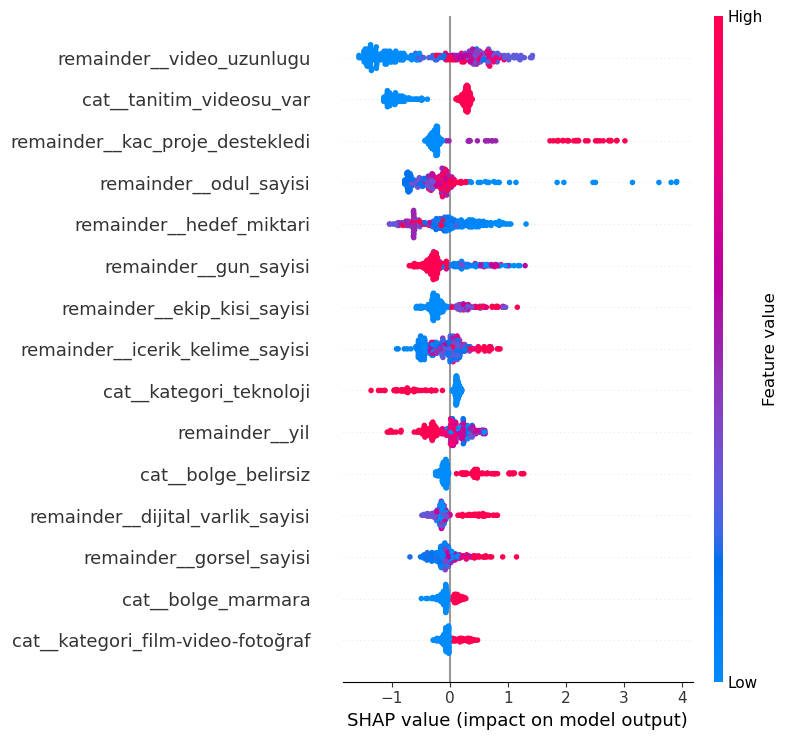

In [103]:
shap.summary_plot(
    shap_values,
    X_test_shap,
    max_display=15
)

### Global SHAP Özeti

Final XGBoost modelinin tahminlerini daha ayrıntılı yorumlamak amacıyla SHAP analizi uygulanmıştır. Pozitif SHAP değerleri model çıktısını başarılı kampanya yönüne, negatif değerler ise başarısız kampanya yönüne taşımaktadır.

SHAP sonuçlarına göre video uzunluğu, tanıtım videosunun bulunması, proje sahibinin geçmiş destek deneyimi, hedef miktarı, kampanya süresi, ekip büyüklüğü ve içerik kelime sayısı model tahminlerinde öne çıkan değişkenlerdir.

Tanıtım videosunun bulunması, daha yüksek dijital varlık sayısı, daha büyük ekip, daha fazla görsel ve daha kapsamlı içerik genel olarak model tahminini başarılı kampanya yönüne taşırken; yüksek hedef miktarının tahmini daha çok başarısızlık yönüne ittiği görülmektedir.

Bununla birlikte SHAP değerleri nedensellik göstermemektedir. Sonuçlar yalnızca modelin mevcut veri setindeki örüntüleri tahmin sırasında nasıl kullandığını açıklamaktadır.

In [104]:
correct_success = np.where(
    (y_test.to_numpy() == 1) &
    (y_pred_threshold == 1)
)[0]

sample_pos = correct_success[0]

sample_probability = y_test_proba[sample_pos]

print("Gerçek sınıf:", y_test.iloc[sample_pos])
print("Tahmin edilen sınıf:", y_pred_threshold[sample_pos])
print("Başarı olasılığı:", round(sample_probability, 3))
print("Karar eşiği:", round(best_threshold, 3))

Gerçek sınıf: 1
Tahmin edilen sınıf: 1
Başarı olasılığı: 0.928
Karar eşiği: 0.451


In [105]:
X_test_fe.iloc[sample_pos]

platform_adi                   fongogo
kitle_fonlamasi_turu              ödül
kategori                  kültür-sanat
fon_sekli                ya hep ya hiç
kac_proje_destekledi                 3
kac_projenin_sahibi                  7
kac_proje_takiminda                  0
bolge                          marmara
yil                               2019
gun_sayisi                          42
tanitim_videosu                    var
video_uzunlugu                     144
gorsel_sayisi                        1
odul_sayisi                          9
ekip_kisi_sayisi                     1
web_sitesi                         var
sosyal_medya                       var
sm_sayisi                            3
etiket_sayisi                        5
icerik_kelime_sayisi               126
hedef_miktari                     6000
dijital_varlik_sayisi                3
Name: 683, dtype: object

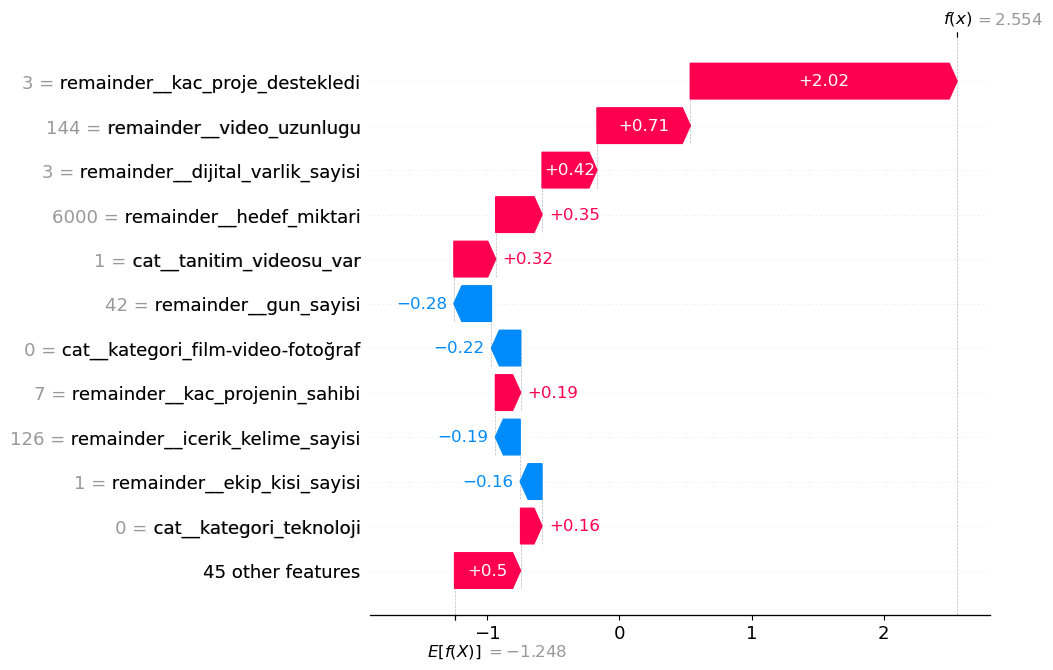

In [106]:
shap_explanation = explainer(X_test_shap)

shap.plots.waterfall(
    shap_explanation[sample_pos],
    max_display=12
)

### Bireysel Tahmin Açıklaması

Modelin doğru şekilde başarılı olarak tahmin ettiği örnek bir kampanya SHAP Waterfall grafiği ile incelenmiştir. Kampanyanın tahmin edilen başarı olasılığı %92.8'dir.

Bu tahminde proje sahibinin daha önce desteklediği proje sayısı, video uzunluğu, dijital varlık sayısı, düşük hedef miktarı ve tanıtım videosunun bulunması başarı yönündeki en güçlü katkıları oluşturmuştur.

Buna karşılık kampanya süresi, düşük içerik kelime sayısı ve tek kişilik ekip gibi bazı özellikler tahmini başarısızlık yönüne çekmiştir. Buna rağmen olumlu katkıların toplam etkisi daha yüksek olduğu için model kampanyayı başarılı olarak sınıflandırmıştır.

SHAP katkıları nedensel etkileri değil, modelin ilgili gözlem için karar verirken özellikleri nasıl kullandığını göstermektedir.

## 23. Modelin Sınırlılıkları ve Güvenilirlik Değerlendirmesi

Model, kampanya başlamadan önce bilinen özellikleri kullanarak kampanya başarısını tahmin etmektedir. Çapraz doğrulama, feature engineering, hiperparametre optimizasyonu ve karar eşiği optimizasyonu ile model performansı geliştirilmiştir.

Bununla birlikte modelin bazı sınırlılıkları bulunmaktadır:

- Veri seti 1628 kampanyadan oluşmaktadır ve bazı kategori, platform ve bölge gruplarında gözlem sayısı oldukça düşüktür.
- Başarılı kampanyalar veri setinin yalnızca %23.1'ini oluşturduğu için sınıf dengesizliği bulunmaktadır.
- Modelde gözlenen ilişkiler nedensellik göstermemektedir.
- Platform, kategori ve bölge gibi değişkenlerdeki başarı örüntüleri gelecekte veya farklı veri setlerinde değişebilir.
- Bazı değişkenler birbiriyle ilişkili bilgiler taşımaktadır. Örneğin tanıtım videosu ve video uzunluğu benzer bilgileri kısmen temsil etmektedir.
- Model gerçek bir yatırım veya fonlama kararı vermek yerine karar destek aracı olarak değerlendirilmelidir.

Final model, test verisinde %84.4 accuracy, başarılı sınıf için 0.667 precision, 0.640 recall ve 0.653 F1-score elde etmiştir. Balanced accuracy değeri 0.772'dir. Model kullanılabilir bir tahmin performansı göstermesine rağmen hatalı pozitif ve hatalı negatif tahminler üretmeye devam ettiği için sonuçlar kesin karar olarak yorumlanmamalıdır.

## 24. Yeni Kampanya Örnekleri

In [ ]:
new_campaigns = pd.DataFrame([
    {
        "platform_adi": "fongogo",
        "kitle_fonlamasi_turu": "ödül",
        "kategori": "eğitim",
        "fon_sekli": "ya hep ya hiç",
        "bolge": "marmara",
        "tanitim_videosu": "var",
        "web_sitesi": "var",
        "sosyal_medya": "var",
        "kac_proje_destekledi": 3,
        "kac_projenin_sahibi": 2,
        "kac_proje_takiminda": 1,
        "yil": 2021,
        "gun_sayisi": 45,
        "video_uzunlugu": 120,
        "gorsel_sayisi": 8,
        "odul_sayisi": 8,
        "ekip_kisi_sayisi": 4,
        "sm_sayisi": 3,
        "etiket_sayisi": 5,
        "icerik_kelime_sayisi": 500,
        "hedef_miktari": 15000
    },

    {
        "platform_adi": "fonbulucu",
        "kitle_fonlamasi_turu": "ödül",
        "kategori": "teknoloji",
        "fon_sekli": "ya hep ya hiç",
        "bolge": "iç anadolu",
        "tanitim_videosu": "var",
        "web_sitesi": "yok",
        "sosyal_medya": "var",
        "kac_proje_destekledi": 1,
        "kac_projenin_sahibi": 1,
        "kac_proje_takiminda": 0,
        "yil": 2021,
        "gun_sayisi": 60,
        "video_uzunlugu": 70,
        "gorsel_sayisi": 4,
        "odul_sayisi": 5,
        "ekip_kisi_sayisi": 2,
        "sm_sayisi": 2,
        "etiket_sayisi": 3,
        "icerik_kelime_sayisi": 300,
        "hedef_miktari": 50000
    },

    {
        "platform_adi": "arikovani",
        "kitle_fonlamasi_turu": "ödül",
        "kategori": "film-video-fotoğraf",
        "fon_sekli": "ya hep ya hiç",
        "bolge": "marmara",
        "tanitim_videosu": "var",
        "web_sitesi": "var",
        "sosyal_medya": "var",
        "kac_proje_destekledi": 5,
        "kac_projenin_sahibi": 3,
        "kac_proje_takiminda": 1,
        "yil": 2020,
        "gun_sayisi": 40,
        "video_uzunlugu": 180,
        "gorsel_sayisi": 12,
        "odul_sayisi": 10,
        "ekip_kisi_sayisi": 5,
        "sm_sayisi": 3,
        "etiket_sayisi": 6,
        "icerik_kelime_sayisi": 650,
        "hedef_miktari": 25000
    },

    {
        "platform_adi": "crowdfon",
        "kitle_fonlamasi_turu": "ödül",
        "kategori": "sağlık-güzellik",
        "fon_sekli": "hepsi kalsın",
        "bolge": "ege",
        "tanitim_videosu": "yok",
        "web_sitesi": "var",
        "sosyal_medya": "var",
        "kac_proje_destekledi": 0,
        "kac_projenin_sahibi": 1,
        "kac_proje_takiminda": 0,
        "yil": 2021,
        "gun_sayisi": 60,
        "video_uzunlugu": 0,
        "gorsel_sayisi": 5,
        "odul_sayisi": 4,
        "ekip_kisi_sayisi": 2,
        "sm_sayisi": 2,
        "etiket_sayisi": 3,
        "icerik_kelime_sayisi": 350,
        "hedef_miktari": 40000
    },

    {
        "platform_adi": "fongogo",
        "kitle_fonlamasi_turu": "ödül",
        "kategori": "diğer",
        "fon_sekli": "hepsi kalsın",
        "bolge": "ege",
        "tanitim_videosu": "yok",
        "web_sitesi": "yok",
        "sosyal_medya": "yok",
        "kac_proje_destekledi": 0,
        "kac_projenin_sahibi": 1,
        "kac_proje_takiminda": 0,
        "yil": 2021,
        "gun_sayisi": 60,
        "video_uzunlugu": 0,
        "gorsel_sayisi": 1,
        "odul_sayisi": 2,
        "ekip_kisi_sayisi": 1,
        "sm_sayisi": 0,
        "etiket_sayisi": 0,
        "icerik_kelime_sayisi": 100,
        "hedef_miktari": 100000
    }
])

In [ ]:
new_campaigns_fe = feature_engineering(new_campaigns)

In [ ]:
new_probabilities = best_xgb.predict_proba(new_campaigns_fe)[:, 1]

new_predictions = (
    new_probabilities >= best_threshold
).astype(int)

In [107]:
prediction_table = pd.DataFrame({
    "Senaryo": [
        "Senaryo 1",
        "Senaryo 2",
        "Senaryo 3",
        "Senaryo 4",
        "Senaryo 5"
    ],
    "Başarı Olasılığı": np.round(new_probabilities, 3),
    "Tahmin": np.where(
        new_predictions == 1,
        "Başarılı",
        "Başarısız"
    )
})

prediction_table

,Senaryo,Başarı Olasılığı,Tahmin
0,Senaryo 1,0.806,Başarılı
1,Senaryo 2,0.024,Başarısız
2,Senaryo 3,0.926,Başarılı
3,Senaryo 4,0.007,Başarısız
4,Senaryo 5,0.007,Başarısız


### Yeni Kampanya Örnekleri Üzerinde Tahmin

Final model, veri setinde bulunmayan beş yeni kampanya senaryosu üzerinde test edilmiştir.

- Senaryo 1 için başarı olasılığı %80.6 olarak hesaplanmış ve kampanya başarılı olarak sınıflandırılmıştır.
- Senaryo 2 için başarı olasılığı %2.4 olarak hesaplanmış ve kampanya başarısız olarak sınıflandırılmıştır.
- Senaryo 3 için başarı olasılığı %92.6 ile en yüksek tahmin elde edilmiş ve kampanya başarılı olarak sınıflandırılmıştır.
- Senaryo 4 ve Senaryo 5 için başarı olasılığı %0.7 olarak hesaplanmış ve her iki kampanya da başarısız olarak sınıflandırılmıştır.

Sonuçlar, modelin farklı kampanya özelliklerine sahip yeni gözlemler için farklı başarı olasılıkları üretebildiğini göstermektedir. Bu tahminler kesin başarı garantisi değil, modelin geçmiş verilerde öğrendiği örüntülere dayalı karar destek çıktılarıdır.

## 25. FundPilot TR Mini Tahmin Uygulaması

In [ ]:
class CikisIstegi(Exception):
    pass


def secim_al(soru, secenekler):
    while True:
        cevap = input(
            f"{soru} ({'/'.join(secenekler)}) "
            "[çıkış için: çıkış]: "
        ).strip().lower()

        if cevap == "çıkış":
            raise CikisIstegi

        if cevap in secenekler:
            return cevap

        print(
            f"Hatalı giriş! Şunlardan birini giriniz: "
            f"{', '.join(secenekler)}"
        )


def sayi_al(soru, minimum=0, tam_sayi=True):
    while True:
        cevap = input(
            f"{soru} [çıkış için: çıkış]: "
        ).strip().lower()

        if cevap == "çıkış":
            raise CikisIstegi

        try:
            if tam_sayi:
                deger = int(cevap)
            else:
                deger = float(cevap)

            if deger < minimum:
                print(
                    f"Değer {minimum} veya daha büyük olmalıdır."
                )
                continue

            return deger

        except ValueError:
            print(
                "Hatalı giriş! Lütfen sayısal bir değer "
                "veya 'çıkış' yazınız."
            )

In [ ]:
def tahmin_et():
    print("=== FundPilot TR | Kampanya Başarı Tahmini ===")
    print("Herhangi bir aşamada çıkmak için 'çıkış' yazabilirsiniz.\n")

    try:
        kampanya = {
            "platform_adi": secim_al(
                "Platform adı",
                sorted(X_train["platform_adi"].unique().tolist())
            ),

            "kitle_fonlamasi_turu": secim_al(
                "Kitle fonlaması türü",
                sorted(X_train["kitle_fonlamasi_turu"].unique().tolist())
            ),

            "kategori": secim_al(
                "Kategori",
                sorted(X_train["kategori"].unique().tolist())
            ),

            "fon_sekli": secim_al(
                "Fon şekli",
                sorted(X_train["fon_sekli"].unique().tolist())
            ),

            "bolge": secim_al(
                "Bölge",
                sorted(X_train["bolge"].unique().tolist())
            ),

            "tanitim_videosu": secim_al(
                "Tanıtım videosu var mı?",
                ["var", "yok"]
            ),

            "web_sitesi": secim_al(
                "Web sitesi var mı?",
                ["var", "yok"]
            ),

            "sosyal_medya": secim_al(
                "Sosyal medya var mı?",
                ["var", "yok"]
            ),

            "kac_proje_destekledi": sayi_al(
                "Daha önce desteklediği proje sayısı"
            ),

            "kac_projenin_sahibi": sayi_al(
                "Proje sahibi olduğu proje sayısı"
            ),

            "kac_proje_takiminda": sayi_al(
                "Takımında yer aldığı proje sayısı"
            ),

            "yil": sayi_al(
                "Kampanya yılı",
                minimum=2000
            ),

            "gun_sayisi": sayi_al(
                "Kampanya süresi (gün)"
            ),

            "video_uzunlugu": sayi_al(
                "Video uzunluğu (saniye, yoksa 0)"
            ),

            "gorsel_sayisi": sayi_al(
                "Görsel sayısı"
            ),

            "odul_sayisi": sayi_al(
                "Ödül sayısı"
            ),

            "ekip_kisi_sayisi": sayi_al(
                "Ekipteki kişi sayısı"
            ),

            "sm_sayisi": sayi_al(
                "Sosyal medya hesabı sayısı"
            ),

            "etiket_sayisi": sayi_al(
                "Etiket sayısı"
            ),

            "icerik_kelime_sayisi": sayi_al(
                "İçerik kelime sayısı"
            ),

            "hedef_miktari": sayi_al(
                "Hedef miktarı",
                minimum=1,
                tam_sayi=False
            )
        }

        # Tutarlılık kontrolleri
        if (
            kampanya["tanitim_videosu"] == "yok"
            and kampanya["video_uzunlugu"] != 0
        ):
            print(
                "\nNot: Tanıtım videosu olmadığı için "
                "video uzunluğu 0 olarak ayarlandı."
            )
            kampanya["video_uzunlugu"] = 0

        if (
            kampanya["sosyal_medya"] == "yok"
            and kampanya["sm_sayisi"] != 0
        ):
            print(
                "\nNot: Sosyal medya olmadığı için "
                "sosyal medya hesabı sayısı 0 olarak ayarlandı."
            )
            kampanya["sm_sayisi"] = 0

        yeni_kampanya = pd.DataFrame([kampanya])

        # Feature engineering
        yeni_kampanya_fe = feature_engineering(yeni_kampanya)

        # Başarı olasılığı
        basari_olasiligi = best_xgb.predict_proba(
            yeni_kampanya_fe
        )[0, 1]

        # Optimize edilmiş karar eşiği
        tahmin = int(
            basari_olasiligi >= best_threshold
        )

        print("\n--- Tahmin Sonucu ---")
        print(
            f"Başarı olasılığı: "
            f"%{basari_olasiligi * 100:.1f}"
        )
        print(
            f"Karar eşiği: "
            f"%{best_threshold * 100:.1f}"
        )

        if tahmin == 1:
            print("Model tahmini: BAŞARILI kampanya")
        else:
            print("Model tahmini: BAŞARISIZ kampanya")

        print(
            "\nNot: Bu sonuç kesin bir başarı garantisi değildir. "
            "Modelin geçmiş kampanyalardan öğrendiği örüntülere "
            "dayalı bir karar destek tahminidir."
        )

    except CikisIstegi:
        print("\nFundPilot TR kapatıldı.")

In [108]:
tahmin_et()

=== FundPilot TR | Kampanya Başarı Tahmini ===
Herhangi bir aşamada çıkmak için 'çıkış' yazabilirsiniz.


FundPilot TR kapatıldı.


### Mini Uygulama Sonucu

Kullanıcının kampanya bilgilerini girebildiği `tahmin_et()` fonksiyonu oluşturulmuştur. Girilen özelliklere feature engineering uygulanmakta, final XGBoost modeli başarı olasılığını hesaplamakta ve cross-validation ile belirlenen %45.1 karar eşiğine göre kampanya başarılı veya başarısız olarak sınıflandırılmaktadır.

Örnek çalıştırmada model kampanya için %80.6 başarı olasılığı üretmiş ve kampanyayı başarılı olarak tahmin etmiştir.

## 26. Final Modelin Kaydedilmesi

In [109]:
import joblib

input_options = {
    "platform_adi": sorted(X_train["platform_adi"].unique().tolist()),
    "kitle_fonlamasi_turu": sorted(
        X_train["kitle_fonlamasi_turu"].unique().tolist()
    ),
    "kategori": sorted(X_train["kategori"].unique().tolist()),
    "fon_sekli": sorted(X_train["fon_sekli"].unique().tolist()),
    "bolge": sorted(X_train["bolge"].unique().tolist())
}

# Uygulamada tekrar kullanılabilmesi için model, karar eşiği ve girdi seçenekleri birlikte kaydediliyor.
final_model_package = {
    "model": best_xgb,
    "threshold": float(best_threshold),
    "input_options": input_options,
    "raw_columns": X_train.columns.tolist()
}

joblib.dump(
    final_model_package,
    "fundpilot_final_model.joblib"
)

print("Final model başarıyla kaydedildi.")

Final model başarıyla kaydedildi.


In [110]:
loaded_package = joblib.load(
    "fundpilot_final_model.joblib"
)

loaded_model = loaded_package["model"]
loaded_threshold = loaded_package["threshold"]

print("Model başarıyla yüklendi.")
print("Karar eşiği:", round(loaded_threshold, 3))

Model başarıyla yüklendi.
Karar eşiği: 0.451


In [111]:
yeni_kampanya = new_campaigns.iloc[[0]].copy()

yeni_kampanya_fe = feature_engineering(yeni_kampanya)

olasilik = loaded_model.predict_proba(
    yeni_kampanya_fe
)[0, 1]

tahmin = int(olasilik >= loaded_threshold)

print(f"Başarı olasılığı: %{olasilik * 100:.1f}")
print(
    "Tahmin:",
    "Başarılı" if tahmin == 1 else "Başarısız"
)

Başarı olasılığı: %80.6
Tahmin: Başarılı


## 27. Sonuç

Bu projede, bir kitle fonlama kampanyasının başlamadan önce bilinen özellikleri kullanılarak başarılı ya da başarısız olarak sonuçlanacağı tahmin edilmeye çalışılmıştır. Veri seti 1628 kampanya ve kampanya öncesinde bilinen platform, kategori, tanıtım videosu, ekip büyüklüğü, hedef miktarı gibi değişkenleri içermektedir; kampanya sürecinde oluşan veya sonucu doğrudan yansıtan değişkenler (ör. `toplanan_tutar`, `destek_orani`, `destekci_sayisi`) leakage riski nedeniyle modelden çıkarılmıştır.

Yöntem olarak sırasıyla baseline Decision Tree, feature engineering (`dijital_varlik_sayisi`), hiperparametre optimizasyonu, Random Forest ve XGBoost modelleri denenmiş; modeller arasındaki seçim cross-validation F1-score kriterine dayandırılmıştır. Final model olan hiperparametre optimizasyonlu XGBoost, eğitim verisi üzerinde belirlenen karar eşiği ile test setinde %84.4 accuracy, 0.653 F1-score ve 0.772 balanced accuracy elde etmiştir.

Model, kampanya öncesi bilinen bilgilerle makul bir tahmin performansı göstermektedir; ancak hatalı pozitif ve hatalı negatif tahminler üretmeye devam etmekte, gözlenen ilişkiler nedensellik taşımamakta ve bazı kategori/bölge/platform gruplarında gözlem sayısı sınırlı kalmaktadır. Bu nedenle model, kesin bir karar mercii değil; proje sahiplerine ve platformlara yönelik bir **karar destek aracı** olarak değerlendirilmelidir.